In [2]:
import os
import subprocess
import sys
from pathlib import Path

colab = "google.colab" in sys.modules

if colab:
    repo_dir = Path("/content/PUC_Redes_Neurais")
    if not repo_dir.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/mdrs-thiago/PUC_Redes_Neurais", str(repo_dir)],
            check=True,
        )
    os.chdir("/content/PUC_Redes_Neurais/pos_grad/lista 1")
    print(f"Diretorio atual: {os.getcwd()}")
else:
    print("Ambiente local detectado; clone/chdir de Colab ignorado.")

Ambiente local detectado; clone/chdir de Colab ignorado.


# Redes Neurais
## 1ª Lista de Exercícios - Classificação de padrões


Estudante:Carlos Alberto de Souza Moreira Junior  Matricula: 2612398

Base de dados: bank_marketing'

### Para cada item da lista de exercício, não esqueça de fazer uma análise pertinente dos resultados obtidos.

### Guia prático

A lista de exercícios é dividida em 4 partes. Cada questão possui as seguintes seções:

* **Rascunho**: neste espaço, você pode escrever qualquer código ou teste que queira fazer, mas que *não* produza a resposta desejada.

* **Resposta**: deve conter trechos do código que produzam artefatos importantes para a análise de resultados, além de comentários e discussões sobre o item.

Não é necessário seguir esta ordem, mas é *altamente recomendável*. O intuito da lista de exercícios **não** é medir o nível de conhecimento em programação, então não se preocupe se o código não estiver da forma mais polida possível. O principal ponto a ser avaliado é a capacidade crítica de entender os fenômenos atrelados aos resultados obtidos e a discussão de resultados para um problema específico.   

Outros pontos importantes:

1. Fique atento com os hiperparâmetros iniciais desta lista. Dependendo do problema, os valores podem mudar. Para encontrar um conjunto de parâmetros razoáveis, siga o seguinte roteiro: 

    * Rode os itens 2.1 e 3.1 com os parâmetros iniciais. Se os dois resultados foram igualmente ruins, modifique os parâmetros do item 3.1 até que o resultado seja relativamente melhor que o 2.1.

    * Após obter esses melhores parâmetros iniciais, rode novamente o item 2.1 com os mesmos hiperparâmetros para uma comparação mais justa. 

2. O resultado de um modelo de Redes Neurais geralmente depende da inicialização de seus pesos. Portanto, para cada questão, obtenha um resultado médio de pelo menos 10 rodadas. A recomendação pessoal é de que faça uso do histórico existente da perda (loss) e acurácia para visualização dos resultados, com plot da média e seu intervalo de confiança em função das épocas.

In [3]:
import numpy as np 
import pandas as pd 
import json
import matplotlib.pyplot as plt 
import seaborn as sns 
from time import sleep
import requests

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader 

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import fetch_openml

from utils import CustomDataset, transform_data, plot_confusion_matrix

from typing import Tuple, Dict, List
from tqdm import tqdm 

#adicionais 
import random
import torch.optim as optim
from sklearn.feature_selection import mutual_info_classif 

In [3]:
def accuracy(y_pred: torch.Tensor, y_test: torch.Tensor) -> float:
    """
    Computes the accuracy of a PyTorch model given the outputs and labels.

    Parameters:
        outputs (torch.Tensor): The model outputs.
        labels (torch.Tensor): The true labels.

    Returns:
        float: The accuracy of the model.
    """
    
    _, predictions = torch.max(y_pred, dim=1)
    correct = torch.sum(predictions == y_test)
    accuracy = correct.float() / y_test.size(0)
    acc = torch.round(accuracy * 100)
    
    return acc

def binary_acc(y_pred: torch.Tensor, y_test: torch.Tensor) -> float:
    """
    Computes the binary accuracy of a PyTorch model given the outputs and labels.

    Parameters:
        outputs (torch.Tensor): The model outputs.
        labels (torch.Tensor): The true labels.

    Returns:
        float: The accuracy of the model.
    """
    
    predictions = torch.round(torch.sigmoid(y_pred))
    correct = torch.sum(predictions == y_test)
    accuracy = correct.float() / y_test.size(0)
    acc = torch.round(accuracy * 100)
    
    return acc

In [4]:
def evaluate(model: torch.nn.Module, val_set: Tuple[torch.tensor, torch.tensor], 
            criterion: torch.nn.Module, binary:bool =True) -> Tuple[torch.tensor, float, float]:
    """
    Evaluates a Pytorch model on a given dataset.
    Parameters:
    model (torch.nn.Module): The model to be evaluated
    data (tuple): A tuple containing the data and labels
    criterion (torch.nn.Module): The loss function to be used
    binary (bool): Boolean indicating whether the task is binary classification or not. Default: True
    Returns:
    tuple: A tuple containing predicted labels, loss, and accuracy
    """
    
    X = val_set.X_data
    y = val_set.y_data
    
    with torch.no_grad():
        y_pred = model(X)
    loss = criterion(y_pred, y)
    if binary:
        acc = binary_acc(y_pred, y)
    else:
        acc = accuracy(y_pred, y)
    y_pred = torch.argmax(y_pred, dim=1)

    return y_pred, loss.item(), acc.item()


In [5]:
def train(model: torch.nn.Module , train_loader: torch.utils.data.DataLoader, 
         val_set: Tuple[torch.Tensor, torch.Tensor], epochs: int, device: torch.device, 
         lr: float, binary: bool = True, skip: int = 1, momentum: float = 0.0) -> Tuple[Dict[str, List[float]], torch.Tensor]:
    """
    Trains a Pytorch model on a given training data.

    Parameters:
    model (torch.nn.Module): The model to be trained
    train_loader (DataLoader): The training data in the form of a Pytorch DataLoader
    val_set (tuple): A tuple containing the validation data and labels
    epochs (int): The number of times the training data should be passed through the model
    device (str or torch.device): The device on which to perform the computations (e.g. 'cpu' or 'cuda')
    lr (float): The learning rate for the optimizer
    binary (bool): Boolean indicating whether the task is binary classification or not. Default: True
    skip (int): The number of epochs after which the training and validation results will be printed. Default: 1
    momentum (float): Momentum for SGD optimizer. Default: 0.0

    Returns:
    tuple: A tuple containing the training history and the predicted labels after training
    """

    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    history = {'acc_train' : [], 'loss_train': [], 'acc_val': [], 'loss_val': []}

    for e in tqdm(range(1, epochs+1)):

        y_hat = np.array([])

        train_epoch_loss = 0
        train_epoch_acc = 0
        model.train()
        for X_train_batch, y_train_batch in train_loader:
            X, y = X_train_batch.to(device), y_train_batch.to(device)
            optimizer.zero_grad()
            
            y_pred = model(X)
            
            loss = criterion(y_pred, y)
            if binary:
                acc = binary_acc(y_pred,y)
            else:
                acc = accuracy(y_pred, y)
            
            loss.backward()
            optimizer.step()
            
            train_epoch_loss += loss.item()
            train_epoch_acc += acc.item()
            y_p = torch.argmax(y_pred, dim=1)
            y_hat = np.concatenate((y_hat, y_p))


        model.eval()
        _, val_loss, val_acc = evaluate(model, val_set, criterion, binary=binary)

        history['acc_train'].append(train_epoch_acc/len(train_loader))
        history['loss_train'].append(train_epoch_loss/len(train_loader))
        history['acc_val'].append(val_acc)
        history['loss_val'].append(val_loss)

        if e%skip == 0:
            print(f'Epoch {e+0:03}: | Train Loss: {train_epoch_loss/len(train_loader):.3f} | Val Loss: {val_loss:.4f} | Train Acc: {train_epoch_acc/len(train_loader):.4f}| Val Acc: {val_acc:.4f}')
    return history, y_hat

In [6]:
class NeuralNetwork(torch.nn.Module):
  '''
  Objeto criado para facilitar o desenvolvimento dos scripts das aulas práticas.
  Opção alternativa à criação externa fdo modelo. Basicamente serve como um 
  'agregador'  de trechos comuns para a criação do modelo. Por exemplo, ao invés
  de gastar n+1 linhas para a criação de um modelo com n camadas, podemos criar 
  o mesmo modelo com apenas uma linha.
  
  Parâmetros de entrada: 
  - hidden_neurons: Lista com a quantidade de neurônios na camada escondida. 
  - hidden_activation: Função de ativação para cada camada escondida. Aceita 
  como parâmetro string ou lista. Caso o parâmetro receba string, então a mesma
  função de ativação é utilizada para todas as camadas escondidas. Caso seja uma 
  lista, cada camada terá sua propria função de ativação definida pela lista.
  - output_activation: Função de ativação para a camada de saída.
  - lr: Taxa de aprendizado
  - n_input: Tamanho do vetor de entrada.
  - n_output: Saída do modelo.
  '''
  def __init__(self,hidden_neurons = 4, hidden_activation = 'relu', output_activation='softmax', lr = 0.05, n_input = 1, n_output = 1):
    super(NeuralNetwork, self).__init__()

    self.activations = {'relu': nn.ReLU(), 'sigmoid':nn.Sigmoid(), 'softmax':nn.Softmax()}

    self.fc1 = nn.Linear(n_input, hidden_neurons)
    self.ha = self.activations[hidden_activation]
    self.fc2 = nn.Linear(hidden_neurons, n_output)

  def forward(self,x):
    h = self.fc1(x)
    h1 = self.ha(h) 
    y = self.fc2(h1) 
    return y

  def predict(self, x, binary=True):
    y_hat = self.forward(x)

    if binary:
      y_pred = torch.round(torch.sigmoid(y_hat))
      y_pred = y_pred.detach().numpy()
    else:
      y_pred = torch.argmax(y_hat, dim=1)

    return y_pred

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/carlos/.local/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


# Preparação dos dados

Não esqueça de verificar o path para a pasta. Mude também o filename, de acordo com a base de dados. Esta parte é necessária para garantir que as colunas sejam corretamente identificadas de acordo com a natureza dos dados.

In [8]:
dataset_name = 'bank_marketing'

if dataset_name == 'bank_marketing':
    # Carrega a base diretamente do OpenML para evitar 404 no repositório do curso.
    bank = fetch_openml(name='BankMarketing', version=1, as_frame=True)
    dataset = bank.frame.copy()
    if 'class' in dataset.columns and 'target' not in dataset.columns:
        dataset = dataset.rename(columns={'class': 'target'})
    if 'y' in dataset.columns and 'target' not in dataset.columns:
        dataset = dataset.rename(columns={'y': 'target'})
    info = {
        col: ('categorical' if dataset[col].dtype == 'object' else 'numerical')
        for col in dataset.columns
    }
    dataset_path = 'openml://BankMarketing'
    info_path = 'generated_from_dtypes'
else:
    dataset_path = f'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets/c_{dataset_name}.csv'
    info_path = f'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets/data_info/{dataset_name}/data_info.json'
    dataset = pd.read_csv(dataset_path)

In [9]:
if dataset_name != 'bank_marketing':
    resp = requests.get(info_path)
    info = json.loads(resp.text)

In [10]:
for col, k in info.items():
    if k == 'categorical':
        dataset[col] = dataset[col].astype(object)

In [11]:
for i in dataset.dtypes.items():
    print(i)

('age', dtype('int64'))
('job', CategoricalDtype(categories=['admin.', 'blue-collar', 'entrepreneur', 'housemaid',
                  'management', 'retired', 'self-employed', 'services',
                  'student', 'technician', 'unemployed', 'unknown'],
, ordered=False, categories_dtype=object))
('marital', CategoricalDtype(categories=['divorced', 'married', 'single', 'unknown'], ordered=False, categories_dtype=object))
('education', CategoricalDtype(categories=['basic.4y', 'basic.6y', 'basic.9y', 'high.school',
                  'illiterate', 'professional.course', 'university.degree',
                  'unknown'],
, ordered=False, categories_dtype=object))
('default', CategoricalDtype(categories=['no', 'unknown', 'yes'], ordered=False, categories_dtype=object))
('housing', CategoricalDtype(categories=['no', 'unknown', 'yes'], ordered=False, categories_dtype=object))
('loan', CategoricalDtype(categories=['no', 'unknown', 'yes'], ordered=False, categories_dtype=object))
('contact', C

In [12]:
# Visao geral do dataset bank_marketing
print(f"Dataset selecionado: {dataset_name}")
print(f"Dimensao: {dataset.shape[0]} linhas x {dataset.shape[1]} colunas")

print("\nPrimeiras 5 linhas:")
display(dataset.head())

print("\nInformacoes das colunas:")
display(dataset.dtypes.to_frame(name='dtype').T)

if 'target' in dataset.columns:
    print("\nDistribuicao da variavel alvo (target):")
    display(dataset['target'].value_counts(dropna=False).to_frame(name='count').T)

Dataset selecionado: bank_marketing
Dimensao: 41188 linhas x 21 colunas

Primeiras 5 linhas:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



Informacoes das colunas:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,target
dtype,int64,category,category,category,category,category,category,category,category,category,...,int64,int64,int64,category,float64,float64,float64,float64,float64,category



Distribuicao da variavel alvo (target):


target,no,yes
count,36548,4640


## Parte I - Compreensão do problema e análise de variáveis

Total: 0,5 pts.


1)	Neste primeiro momento, iremos verificar a qualidade dos dados. Verifique se os dados estão aptos para o treinamento de Redes Neurais (i.e., verifique a existência de dados nulos, atributos de identificação ou duplicados). Implemente o código que execute as técnicas necessárias e discuta o racional utilizado para o tratamento de dados. 

Rascunho

In [13]:
# PSEUDOCODIGO (Rascunho)
# 1. Inspecionar dimensao da base e tipos das colunas.
# 2. Verificar dados nulos por coluna.
# 3. Verificar duplicatas completas e remover, se houver.
# 4. Procurar colunas candidatas a identificador (nome com "id" ou alta cardinalidade).
# 5. Definir estrategia de tratamento e aplicar no dataset.


In [14]:
 
new_df = transform_data(dataset, normalize=False)
#new_df.head() 


In [15]:
new_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Resposta

1) INSPECAO INICIAL DA BASE
- Dimensao inicial: 41188 linhas x 21 colunas
- Tipos das colunas (amostra):
age               int64
job            category
marital        category
education      category
default        category
housing        category
loan           category
contact        category
month          category
day_of_week    category
dtype: object

2) DADOS NULOS
- Nao foram encontrados valores nulos explicitos.

3) DUPLICATAS
- Duplicatas completas antes: 12
- Duplicatas completas depois: 0
- Acao: duplicatas removidas com drop_duplicates().

4) ATRIBUTOS CANDIDATOS A IDENTIFICADOR
- Candidatas encontradas: ['cons.price.idx', 'cons.conf.idx']
- Colunas efetivamente removidas: ['cons.price.idx', 'cons.conf.idx']

5) CATEGORIAS UNKNOWN POR COLUNA CATEGORICA


- Tabela geral de unknown por coluna:


,coluna,qtd_unknown,pct_unknown
0,default,8596,20.88
1,education,1730,4.20
2,housing,990,2.40
3,loan,990,2.40
4,job,330,0.80
5,marital,80,0.19


- Mini tabela (colunas foco):


,coluna,qtd_unknown,pct_unknown
0,education,1730,4.2
1,job,330,0.8


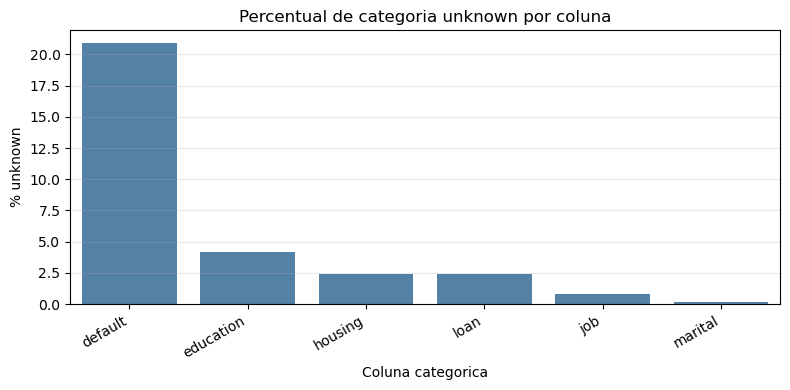


6) DISTRIBUICAO DA VARIAVEL-ALVO
- Contagem por classe:
target
no     36537
yes     4639
Name: count, dtype: int64
- Percentual por classe (%):
target
no     88.73
yes    11.27
Name: count, dtype: float64
- Razao majoritaria/minoritaria: 7.88
- Observacao: ha desbalanceamento relevante; accuracy isolada pode ser enganosa.

7) ESTRATEGIA APLICADA
- Estrategia: remover duplicatas e remover possiveis identificadores (quando encontrados).
- Ressalva: categorias como "unknown" e o possivel desbalanceamento da classe-alvo exigem cuidado na analise.
- Dimensao final apos tratamento: 41176 linhas x 19 colunas

Conclusao da Questao 1: base utilizavel para as proximas etapas, com ressalvas sobre categorias "unknown" e sobre o desbalanceamento da classe-alvo.


In [16]:
def check_data_quality(df: pd.DataFrame, target_col: str = 'target', id_threshold: float = 0.98) -> dict:
    nulls = df.isna().sum()
    n_duplicates = int(df.duplicated().sum())

    id_candidates = []
    for col in df.columns:
        if col == target_col:
            continue
        unique_ratio = df[col].nunique(dropna=False) / max(len(df), 1)
        if ('id' in col.lower()) or (unique_ratio >= id_threshold):
            id_candidates.append(col)

    target_dist = None
    if target_col in df.columns:
        target_dist = df[target_col].value_counts(dropna=False)

    return {
        'shape': df.shape,
        'dtypes': df.dtypes,
        'nulls': nulls,
        'n_duplicates': n_duplicates,
        'id_candidates': id_candidates,
        'target_dist': target_dist
    }


def clean_data_for_nn(df: pd.DataFrame, target_col: str = 'target', drop_id_candidates: bool = True,
                      id_threshold: float = 0.98) -> tuple[pd.DataFrame, dict]:
    df_clean = df.copy()
    report_before = check_data_quality(df_clean, target_col=target_col, id_threshold=id_threshold)

    if report_before['n_duplicates'] > 0:
        df_clean = df_clean.drop_duplicates().reset_index(drop=True)

    removed_cols = []
    if drop_id_candidates and report_before['id_candidates']:
        removed_cols = [c for c in report_before['id_candidates'] if c in df_clean.columns]
        if removed_cols:
            df_clean = df_clean.drop(columns=removed_cols)

    report_after = check_data_quality(df_clean, target_col=target_col, id_threshold=id_threshold)
    report_after['removed_id_cols'] = removed_cols

    return df_clean, {'before': report_before, 'after': report_after}


# Executa analise
cleaned_dataset_q1, quality_report_q1 = clean_data_for_nn(
    dataset,
    target_col='target',
    drop_id_candidates=True
)

# 1) Inspecionar dimensao da base e tipos das colunas
print('1) INSPECAO INICIAL DA BASE')
print(f"- Dimensao inicial: {quality_report_q1['before']['shape'][0]} linhas x {quality_report_q1['before']['shape'][1]} colunas")
print('- Tipos das colunas (amostra):')
print(quality_report_q1['before']['dtypes'].head(10))

# 2) Verificar dados nulos por coluna
print('\n2) DADOS NULOS')
nulls_before = quality_report_q1['before']['nulls']
nulls_nonzero = nulls_before[nulls_before > 0]
if len(nulls_nonzero) == 0:
    print('- Nao foram encontrados valores nulos explicitos.')
else:
    print('- Colunas com nulos:')
    print(nulls_nonzero)

# 3) Verificar duplicatas completas e remover, se houver
print('\n3) DUPLICATAS')
print(f"- Duplicatas completas antes: {quality_report_q1['before']['n_duplicates']}")
print(f"- Duplicatas completas depois: {quality_report_q1['after']['n_duplicates']}")
if quality_report_q1['before']['n_duplicates'] > 0:
    print('- Acao: duplicatas removidas com drop_duplicates().')
else:
    print('- Acao: nenhuma remocao necessaria.')

# 4) Procurar colunas candidatas a identificador
print('\n4) ATRIBUTOS CANDIDATOS A IDENTIFICADOR')
print(f"- Candidatas encontradas: {quality_report_q1['before']['id_candidates']}")
print(f"- Colunas efetivamente removidas: {quality_report_q1['after']['removed_id_cols']}")

# 5) Frequencia de categoria unknown por coluna categorica
print('\n5) CATEGORIAS UNKNOWN POR COLUNA CATEGORICA')
cat_cols = [
    c for c in cleaned_dataset_q1.select_dtypes(include=['object', 'category']).columns.tolist()
    if c != 'target'
]

unknown_rows = []
for col in cat_cols:
    col_as_str = cleaned_dataset_q1[col].astype(str).str.strip().str.lower()
    unknown_count = int((col_as_str == 'unknown').sum())
    if unknown_count > 0:
        unknown_pct = 100.0 * unknown_count / max(len(cleaned_dataset_q1), 1)
        unknown_rows.append({
            'coluna': col,
            'qtd_unknown': unknown_count,
            'pct_unknown': unknown_pct
        })

if len(unknown_rows) == 0:
    print('- Nenhuma categoria "unknown" encontrada nas colunas categoricas.')
    df_unknown = pd.DataFrame(columns=['coluna', 'qtd_unknown', 'pct_unknown'])
else:
    df_unknown = pd.DataFrame(unknown_rows).sort_values('pct_unknown', ascending=False).reset_index(drop=True)
    df_unknown['pct_unknown'] = df_unknown['pct_unknown'].round(2)

    print('- Tabela geral de unknown por coluna:')
    display(df_unknown)

    foco_cols = [c for c in ['job', 'education', 'contact', 'poutcome'] if c in df_unknown['coluna'].values]
    if foco_cols:
        print('- Mini tabela (colunas foco):')
        display(df_unknown[df_unknown['coluna'].isin(foco_cols)].reset_index(drop=True))

    plt.figure(figsize=(8, 4))
    sns.barplot(data=df_unknown, x='coluna', y='pct_unknown', color='steelblue')
    plt.title('Percentual de categoria unknown por coluna')
    plt.xlabel('Coluna categorica')
    plt.ylabel('% unknown')
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 6) Verificar distribuicao da variavel-alvo (desbalanceamento)
print('\n6) DISTRIBUICAO DA VARIAVEL-ALVO')
target_dist = quality_report_q1['after']['target_dist']
if target_dist is not None:
    target_pct = (target_dist / target_dist.sum() * 100).round(2)
    print('- Contagem por classe:')
    print(target_dist)
    print('- Percentual por classe (%):')
    print(target_pct)

    if len(target_dist) >= 2:
        maj = target_dist.max()
        minv = target_dist.min()
        imbalance_ratio = maj / max(minv, 1)
        print(f'- Razao majoritaria/minoritaria: {imbalance_ratio:.2f}')
        if imbalance_ratio >= 2.0:
            print('- Observacao: ha desbalanceamento relevante; accuracy isolada pode ser enganosa.')
        else:
            print('- Observacao: desbalanceamento baixo ou moderado.')

# 7) Definir estrategia de tratamento e aplicar no dataset
print('\n7) ESTRATEGIA APLICADA')
print('- Estrategia: remover duplicatas e remover possiveis identificadores (quando encontrados).')
print('- Ressalva: categorias como "unknown" e o possivel desbalanceamento da classe-alvo exigem cuidado na analise.')
print(f"- Dimensao final apos tratamento: {quality_report_q1['after']['shape'][0]} linhas x {quality_report_q1['after']['shape'][1]} colunas")

# Atualiza base para os proximos itens
dataset = cleaned_dataset_q1.copy()
print('\nConclusao da Questao 1: base utilizavel para as proximas etapas, com ressalvas sobre categorias "unknown" e sobre o desbalanceamento da classe-alvo.')

### Comentarios


A inspeção inicial mostrou que a base possui 41.188 linhas e 21 colunas, o que já indica um conjunto de dados suficientemente grande para o treinamento de uma rede neural. Do ponto de vista estrutural, a base está relativamente bem organizada: não foram encontrados valores nulos explícitos, e as 12 duplicatas completas detectadas foram removidas. Esse passo de limpeza é importante porque evita que o modelo seja treinado com observações repetidas, o que poderia distorcer a estimação e inflar artificialmente o desempenho.

Outro ponto relevante da análise foi a verificação da presença de categorias unknown nas variáveis categóricas. Os maiores percentuais apareceram em default (20,88%) e education (4,20%), seguidos por housing e loan (2,40% cada). Isso mostra que o principal cuidado nesta base não está na ausência explícita de valores, mas sim em informações ambíguas codificadas como categoria. Do ponto de vista de modelagem, isso é importante porque esses valores podem carregar ausência de informação disfarçada de resposta válida.

Por fim, a distribuição da variável-alvo indica um desbalanceamento relevante, com aproximadamente 88,73% de exemplos da classe majoritária e 11,27% da classe minoritária. Esse resultado já antecipa uma conclusão importante para as etapas seguintes: a acurácia isolada não será suficiente para avaliar a qualidade do modelo. Assim, esta etapa cumpriu bem o papel de mostrar que a base está utilizável, mas com duas ressalvas importantes — presença de unknown em algumas variáveis categóricas e desbalanceamento da classe-alvo — que precisam ser levadas em conta em toda a análise posterior.

2) Utilize técnicas de seleção de variáveis e visualização de gráficos para compreender melhor a relação entre as variáveis do problema. Avalie e discuta os resultados obtidos. 

Rascunho

In [17]:
# PSEUDOCODIGO (Rascunho)
# 1. Converter variaveis categoricas para formato numerico (one-hot/label).
# 2. Medir relevancia de atributos para o alvo (correlacao e informacao mutua).
# 3. Visualizar relacoes mais fortes com heatmap.
# 4. Selecionar subconjunto de atributos mais informativos para analise.

Resposta

In [18]:
#sns.pairplot(dataset, hue="target", diag_kind="hist")

1) CONVERSAO DE VARIAVEIS CATEGORICAS
- Total de variaveis originais (sem alvo): 18
- Variaveis categoricas: 10
- Variaveis numericas: 8
- Total de variaveis apos one-hot: 61
- Exemplo de colunas apos codificacao:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'euribor3m', 'nr.employed', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed']

1.1) REDUNDANCIA EM PARES ONE-HOT COMPLEMENTARES
- Foram encontrados 1 pares binarios potencialmente redundantes.
- Exemplos (par e correlacao):
  contact_cellular x contact_telephone | corr=-1.0000
- Observacao: esses pares carregam informacao espelhada e podem inflar redundancia.

2) RELEVANCIA DAS VARIAVEIS (CORRELACAO E INFORMACAO MUTUA)
- Top 12 por informacao mutua:
duration                0.076998
euribor3m               0.073902
nr.employed             0.063391
emp.var.rate            0.055378
pdays                   0.040278
poutcome_success        

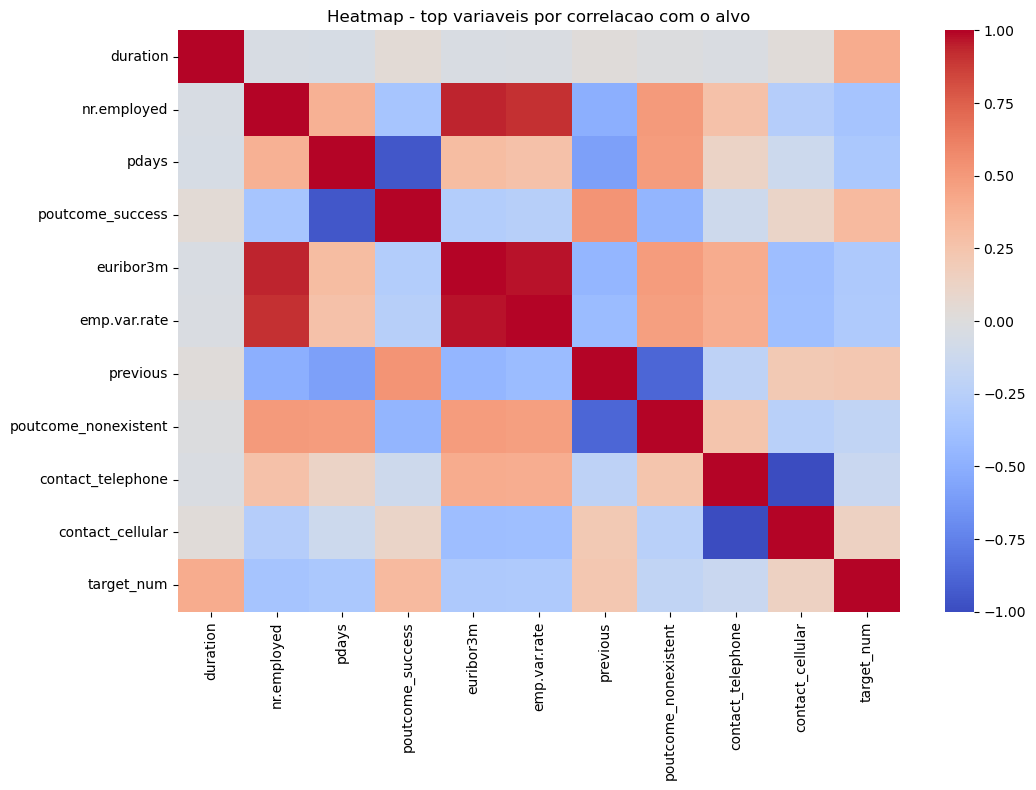


4) SUBCONJUNTO DE ATRIBUTOS MAIS INFORMATIVOS
- Quantidade de atributos selecionados: 8
- Atributos selecionados:
['duration', 'emp.var.rate', 'euribor3m', 'nr.employed', 'pdays', 'poutcome_nonexistent', 'poutcome_success', 'previous']

- Ranking combinado (top 15):


,mi_score,abs_corr_target
duration,0.076998,0.405297
euribor3m,0.073902,0.307740
nr.employed,0.063391,0.354669
emp.var.rate,0.055378,0.298289
pdays,0.040278,0.324948
poutcome_success,0.028556,0.316302
poutcome_nonexistent,0.022100,0.193522
previous,0.018955,0.230202
contact_cellular,0.017814,0.144774
contact_telephone,0.015535,0.144774



5) ABLACAO: RANKING COM E SEM DURATION
- Ranking lado a lado (top 10):


,top_mi_com_duration,top_mi_sem_duration,top_corr_com_duration,top_corr_sem_duration
0,duration,euribor3m,duration,nr.employed
1,euribor3m,nr.employed,nr.employed,pdays
2,nr.employed,emp.var.rate,pdays,poutcome_success
3,emp.var.rate,pdays,poutcome_success,euribor3m
4,pdays,poutcome_success,euribor3m,emp.var.rate
5,poutcome_success,poutcome_nonexistent,emp.var.rate,previous
6,poutcome_nonexistent,previous,previous,poutcome_nonexistent
7,previous,contact_cellular,poutcome_nonexistent,contact_telephone
8,contact_cellular,contact_telephone,contact_telephone,contact_cellular
9,contact_telephone,default_no,contact_cellular,month_mar


- Sobreposicao top-10 MI (com vs sem duration): 9/10
- Sobreposicao top-10 correlacao (com vs sem duration): 9/10

6) OPCIONAL: REMOVER UMA COLUNA POR PAR COMPLEMENTAR
- Colunas removidas por redundancia complementar: ['contact_telephone']
- Dimensao antes: 61 | depois: 60
- Ranking lado a lado (original vs reduzido):


,top_mi_original,top_mi_reduzido,top_corr_original,top_corr_reduzido
0,duration,duration,duration,duration
1,euribor3m,euribor3m,nr.employed,nr.employed
2,nr.employed,nr.employed,pdays,pdays
3,emp.var.rate,emp.var.rate,poutcome_success,poutcome_success
4,pdays,pdays,euribor3m,euribor3m
5,poutcome_success,poutcome_success,emp.var.rate,emp.var.rate
6,poutcome_nonexistent,poutcome_nonexistent,previous,previous
7,previous,previous,poutcome_nonexistent,poutcome_nonexistent
8,contact_cellular,contact_cellular,contact_telephone,contact_cellular
9,contact_telephone,age,contact_cellular,month_mar


- Sobreposicao top-10 MI (original vs reduzido): 9/10
- Sobreposicao top-10 correlacao (original vs reduzido): 9/10

Conclusao da Questao 2: alem do ranking original, foi incluida evidencia empirica por ablacao sem duration e teste opcional de remocao de colinearidade complementar.


In [ ]:
def build_rankings(X_df: pd.DataFrame, y_arr: np.ndarray, random_state: int = 42):
    mi_values_local = mutual_info_classif(X_df.values, y_arr, random_state=random_state)
    mi_series_local = pd.Series(mi_values_local, index=X_df.columns).sort_values(ascending=False)

    corr_local_df = X_df.copy()
    corr_local_df['target_num'] = y_arr
    corr_series_local = (
        corr_local_df
        .corr(numeric_only=True)['target_num']
        .drop('target_num')
        .abs()
        .sort_values(ascending=False)
    )

    ranking_local = pd.DataFrame({
        'mi_score': mi_series_local,
        'abs_corr_target': corr_series_local.reindex(mi_series_local.index).fillna(0)
    }).sort_values(['mi_score', 'abs_corr_target'], ascending=False)

    return mi_series_local, corr_series_local, ranking_local


# Copia da base para analise
q2_df = dataset.copy()
target_col = 'target'

if target_col not in q2_df.columns:
    raise ValueError(f"Coluna alvo '{target_col}' nao encontrada no dataset.")

# 1) Converter variaveis categoricas para formato numerico (one-hot/label)
print('1) CONVERSAO DE VARIAVEIS CATEGORICAS')
feature_df = q2_df.drop(columns=[target_col]).copy()

cat_cols = feature_df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in feature_df.columns if c not in cat_cols]

print(f'- Total de variaveis originais (sem alvo): {feature_df.shape[1]}')
print(f'- Variaveis categoricas: {len(cat_cols)}')
print(f'- Variaveis numericas: {len(num_cols)}')

X_q2 = pd.get_dummies(feature_df, columns=cat_cols, drop_first=False)
y_q2 = LabelEncoder().fit_transform(q2_df[target_col])

print(f'- Total de variaveis apos one-hot: {X_q2.shape[1]}')
print('- Exemplo de colunas apos codificacao:')
print(X_q2.columns[:15].tolist())

# 1.1) Checar possiveis redundancias em pares complementares do one-hot
print('\n1.1) REDUNDANCIA EM PARES ONE-HOT COMPLEMENTARES')
complementary_pairs = []
for col in cat_cols:
    vals = sorted(feature_df[col].dropna().astype(str).unique().tolist())
    if len(vals) == 2:
        c1 = f'{col}_{vals[0]}'
        c2 = f'{col}_{vals[1]}'
        if c1 in X_q2.columns and c2 in X_q2.columns:
            pair_corr = X_q2[[c1, c2]].corr().iloc[0, 1]
            complementary_pairs.append((col, c1, c2, pair_corr))

if complementary_pairs:
    print(f'- Foram encontrados {len(complementary_pairs)} pares binarios potencialmente redundantes.')
    print('- Exemplos (par e correlacao):')
    for item in complementary_pairs[:5]:
        print(f'  {item[1]} x {item[2]} | corr={item[3]:.4f}')
    print('- Observacao: esses pares carregam informacao espelhada e podem inflar redundancia.')
else:
    print('- Nenhum par complementar binario detectado automaticamente.')

# 2) Medir relevancia de atributos para o alvo (correlacao e informacao mutua)
print('\n2) RELEVANCIA DAS VARIAVEIS (CORRELACAO E INFORMACAO MUTUA)')
mi_series, corr_target, ranking_q2 = build_rankings(X_q2, y_q2, random_state=42)

top_n = 12
top_mi = mi_series.head(top_n)
top_corr = corr_target.head(top_n)

print(f'- Top {top_n} por informacao mutua:')
print(top_mi)
print(f'\n- Top {top_n} por |correlacao| com o alvo:')
print(top_corr)

# 2.1) Alerta interpretativo para variavel duration
print('\n2.1) ALERTA INTERPRETATIVO PARA VARIAVEL DURATION')
duration_cols = [c for c in X_q2.columns if c == 'duration' or c.startswith('duration_')]
if duration_cols:
    duration_in_top_mi = [c for c in duration_cols if c in top_mi.index]
    duration_in_top_corr = [c for c in duration_cols if c in top_corr.index]
    print(f'- Colunas relacionadas a duration detectadas: {duration_cols[:3]}')
    if duration_in_top_mi or duration_in_top_corr:
        print('- Duration aparece entre as variaveis mais fortes no ranking.')
        print('- Observacao: isso pode elevar desempenho por proximidade com o desfecho e exige cuidado de interpretacao.')
    else:
        print('- Duration nao apareceu no top atual, mas ainda deve ser monitorada em analises futuras.')
else:
    print('- Nao ha coluna duration identificada apos preprocessamento.')

# 3) Visualizar relacoes mais fortes com heatmap
print('\n3) HEATMAP DAS RELACOES MAIS FORTES')
top_heat_cols = top_corr.head(10).index.tolist()
heat_df = X_q2[top_heat_cols].copy()
heat_df['target_num'] = y_q2
heat_df = heat_df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(heat_df, cmap='coolwarm', center=0, annot=False)
plt.title('Heatmap - top variaveis por correlacao com o alvo')
plt.tight_layout()
plt.show()

# 4) Selecionar subconjunto de atributos mais informativos para analise
print('\n4) SUBCONJUNTO DE ATRIBUTOS MAIS INFORMATIVOS')
selected_features_q2 = sorted(set(top_mi.head(8).index.tolist() + top_corr.head(8).index.tolist()))
X_selected_q2 = X_q2[selected_features_q2].copy()

print(f'- Quantidade de atributos selecionados: {len(selected_features_q2)}')
print('- Atributos selecionados:')
print(selected_features_q2)

print('\n- Ranking combinado (top 15):')
display(ranking_q2.head(15))

# 5) repetir ranking sem a variavel duration
print('\n5) ABLACAO: RANKING COM E SEM DURATION')
if duration_cols:
    X_q2_no_duration = X_q2.drop(columns=duration_cols, errors='ignore').copy()
    mi_series_no_duration, corr_target_no_duration, ranking_q2_no_duration = build_rankings(
        X_q2_no_duration,
        y_q2,
        random_state=42
    )

    top_k = 10
    side_by_side = pd.DataFrame({
        'top_mi_com_duration': mi_series.head(top_k).index,
        'top_mi_sem_duration': mi_series_no_duration.head(top_k).index,
        'top_corr_com_duration': corr_target.head(top_k).index,
        'top_corr_sem_duration': corr_target_no_duration.head(top_k).index
    })

    print('- Ranking lado a lado (top 10):')
    display(side_by_side)

    overlap_mi = len(set(mi_series.head(top_k).index) & set(mi_series_no_duration.head(top_k).index))
    overlap_corr = len(set(corr_target.head(top_k).index) & set(corr_target_no_duration.head(top_k).index))

    print(f'- Sobreposicao top-{top_k} MI (com vs sem duration): {overlap_mi}/{top_k}')
    print(f'- Sobreposicao top-{top_k} correlacao (com vs sem duration): {overlap_corr}/{top_k}')
else:
    X_q2_no_duration = X_q2.copy()
    ranking_q2_no_duration = ranking_q2.copy()
    print('- Duration nao encontrada: ablação sem duration nao aplicavel nesta base.')

# 6) Opcional: remover uma coluna de cada par perfeitamente colinear
print('\n6) OPCIONAL: REMOVER UMA COLUNA POR PAR COMPLEMENTAR')
pairs_perfect = [p for p in complementary_pairs if np.isclose(p[3], -1.0, atol=1e-12)]

if pairs_perfect:
    cols_drop_redundant = sorted({p[2] for p in pairs_perfect})
    X_q2_reduced = X_q2.drop(columns=cols_drop_redundant, errors='ignore').copy()
    mi_series_reduced, corr_target_reduced, ranking_q2_reduced = build_rankings(X_q2_reduced, y_q2, random_state=42)

    print(f'- Colunas removidas por redundancia complementar: {cols_drop_redundant}')
    print(f'- Dimensao antes: {X_q2.shape[1]} | depois: {X_q2_reduced.shape[1]}')

    top_k_reduced = 10
    overlap_mi_reduced = len(set(mi_series.head(top_k_reduced).index) & set(mi_series_reduced.head(top_k_reduced).index))
    overlap_corr_reduced = len(set(corr_target.head(top_k_reduced).index) & set(corr_target_reduced.head(top_k_reduced).index))

    compare_reduced = pd.DataFrame({
        'top_mi_original': mi_series.head(top_k_reduced).index,
        'top_mi_reduzido': mi_series_reduced.head(top_k_reduced).index,
        'top_corr_original': corr_target.head(top_k_reduced).index,
        'top_corr_reduzido': corr_target_reduced.head(top_k_reduced).index
    })

    print('- Ranking lado a lado (original vs reduzido):')
    display(compare_reduced)
    print(f'- Sobreposicao top-{top_k_reduced} MI (original vs reduzido): {overlap_mi_reduced}/{top_k_reduced}')
    print(f'- Sobreposicao top-{top_k_reduced} correlacao (original vs reduzido): {overlap_corr_reduced}/{top_k_reduced}')
else:
    X_q2_reduced = X_q2.copy()
    ranking_q2_reduced = ranking_q2.copy()
    print('- Nao houve pares perfeitamente complementares para remocao opcional.')

print('\nConclusao da Questao 2: alem do ranking original, foi incluida evidencia empirica por ablacao sem duration e teste opcional de remocao de colinearidade complementar.')

### Comentários

Nesta etapa, a combinação entre codificação one-hot, informação mútua e correlação com o alvo foi uma escolha metodológica adequada para explorar a relevância das variáveis. A informação mútua é útil porque capta dependências mais gerais e não necessariamente lineares, enquanto a correlação ajuda a identificar associações mais diretas. O uso conjunto dessas duas abordagens torna a análise mais robusta e evita conclusões baseadas em um único critério de importância.

Os resultados mostram que variáveis como duration, euribor3m, nr.employed, emp.var.rate, pdays e poutcome_success aparecem entre as mais relevantes. Esse padrão sugere que existe um núcleo relativamente estável de atributos informativos para o problema. Além disso, a análise de redundância entre variáveis one-hot identificou o par contact_cellular e contact_telephone com correlação -1,0000, o que indica informação espelhada. Isso é importante porque mostra que a codificação pode introduzir redundâncias artificiais e que uma análise cuidadosa da matriz de correlação ajuda a evitar excesso de colinearidade.

O ponto mais forte desta questão foi a análise de estabilidade do ranking com e sem duration. Como a sobreposição entre os top-10 permaneceu muito alta, a conclusão fica mais sólida: embora duration seja muito relevante, a estrutura do problema não depende exclusivamente dela. Os gráficos e tabelas reforçam que a etapa exploratória não serviu apenas para “listar variáveis importantes”, mas para justificar de maneira consistente por que algumas colunas parecem ter maior poder preditivo e por que certas escolhas de pré-processamento fazem sentido antes do treinamento.

## Parte II. Treinamento do modelo de Rede Neural - Baseline e Efeito da Normalização 

Total: 1,5 pts.

1)	Neste momento, iremos fazer a primeira avaliação de resultados do modelo MLP. Com base no que foi aprendido em sala de aula, escolha um valor inicial para os hiperparâmetros `lr` (taxa de aprendizado), `epochs` (número de épocas), `hidden_neurons` (número de neurônios na camada escondida) e `batch_size` (tamanho do lote), justificando sua escolha. Faça o treinamento e responda observando o resultado do treinamento: o modelo foi capaz de aprender? O que pode ser possível inferir sobre a capacidade de generalização?

#### Rascunho

In [20]:
# PSEUDOCODIGO (Rascunho alinhado com a implementacao da Resposta)
# 1. Definir hiperparametros iniciais do baseline (lr, epocas, neuronios, batch, otimizador).
# 2. Treinar baseline de referencia (seed fixa) para leitura principal do item 1.
# 3. Observar metricas e curvas de treino/validacao do baseline.
# 4. Repetir o baseline em multiplas seeds para medir estabilidade (media e IC95).
# 5. Fazer comparacao justa sem/com normalizacao mantendo os mesmos hiperparametros do baseline.
# 6. Nao ajustar hiperparametros nesta celula; ajustes ficam para itens seguintes, se necessario.


In [ ]:
# Baseline inicial para o item 1 da Parte II
lr = 0.01
epochs = 80
hidden_neurons = 24
batch_size = 64
print(f"Baseline: lr={lr} | epochs={epochs} | hidden_neurons={hidden_neurons} | batch_size={batch_size}")

Baseline: lr=0.01 | epochs=80 | hidden_neurons=24 | batch_size=64


In [23]:
new_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,euribor3m,nr.employed,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,4.857,5191.0,no


In [24]:
X_df = new_df.drop(columns=['target']).copy()
X_df = pd.get_dummies(X_df, drop_first=False)
X = X_df.values.astype('float')
target = new_df['target'].values

encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
  print('Binary classification')
  n_output = 1
  binary = True
else:
  print('Multiclass classification')
  n_output = len(encoder.classes_)
  binary = False


Binary classification


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

In [26]:
if binary:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
else:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

if 'batch_size' not in globals():
    batch_size = 32
    print('batch_size nao definido; usando batch_size=32')
else:
    print(f'batch_size ja definido; usando batch_size={batch_size}')

train_loader = DataLoader(dataset=train_dataset, batch_size=int(batch_size))
val_loader = DataLoader(dataset=val_dataset, batch_size=1)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

batch_size ja definido; usando batch_size=64


In [27]:
if 'hidden_neurons' not in globals():
    hidden_neurons = 24
    print('hidden_neurons nao definido; usando hidden_neurons=24')

model = NeuralNetwork(n_input=n_input, hidden_neurons=hidden_neurons, n_output=n_output, output_activation='sigmoid')

In [28]:
if 'epochs' not in globals():
    epochs = 80
    print('epochs nao definido; usando epochs=80')

if 'lr' not in globals():
    lr = 0.01
    print('lr nao definido; usando lr=0.01')

if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'device nao definido; usando device={device}')

history, y_hat = train(model, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  2%|▎         | 2/80 [00:00<00:14,  5.28it/s]

Epoch 001: | Train Loss: 1577.864 | Val Loss: 0.4149 | Train Acc: 88.5922| Val Acc: 89.0000
Epoch 002: | Train Loss: 0.387 | Val Loss: 0.3686 | Train Acc: 88.9417| Val Acc: 89.0000


  5%|▌         | 4/80 [00:00<00:14,  5.15it/s]

Epoch 003: | Train Loss: 0.362 | Val Loss: 0.3556 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 004: | Train Loss: 0.354 | Val Loss: 0.3511 | Train Acc: 88.9417| Val Acc: 89.0000


  8%|▊         | 6/80 [00:01<00:14,  5.20it/s]

...

Epoch 077: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


 98%|█████████▊| 78/80 [00:15<00:00,  4.44it/s]

Epoch 078: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


100%|██████████| 80/80 [00:16<00:00,  4.93it/s]

Epoch 079: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 080: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


Resposta

In [4]:
# Define a seed global para todos os geradores de números aleatórios (Python, numpy, torch)
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Realiza a divisão dos dados em treino/teste (e validação), tentando usar estratificação.
# Se não for possível estratificar (ex: target contínuo), faz split sem stratify.
def safe_split(X, y, test_size=0.2, random_state=42):
    try:
        return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)
    except ValueError:
        return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=None)

# Normaliza apenas as colunas numéricas do DataFrame (z-score), ignorando a coluna alvo.
def normalize_numeric_only(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    df_norm = df.copy()
    num_cols = df_norm.drop(columns=[target_col], errors="ignore").select_dtypes(include=[np.number]).columns
    for col in num_cols:
        std = df_norm[col].std(ddof=0)
        if pd.notna(std) and std != 0:
            df_norm[col] = (df_norm[col] - df_norm[col].mean()) / std
    return df_norm

# Executa um experimento completo de treinamento e avaliação do MLP, repetindo por múltiplas seeds.
# Parâmetros:
#   - dataset: dados de entrada
#   - normalize: se True, normaliza as colunas numéricas
#   - cfg: dicionário de hiperparâmetros
#   - n_runs: número de repetições (seeds)
# Retorna:
#   - runs: lista de resultados de cada rodada
#   - summary: métricas agregadas (média e std de accuracy, f1, etc)
def run_scenario(dataset, normalize: bool, cfg: dict, n_runs: int = 10):
    runs = []

    for seed in range(n_runs):
        set_seed(seed)  # Garante reprodutibilidade

        print("\n" + "=" * 80)
        print(f"Rodada {seed + 1}/{n_runs} | normalize={normalize}")
        print("=" * 80)

        # Carrega e transforma os dados (sem normalizar ainda)
        df = transform_data(dataset, normalize=False)

        # Se solicitado, normaliza só as colunas numéricas
        if normalize:
            df = normalize_numeric_only(df, target_col="target")

        # Prepara X (features) e y (target)
        X_df = df.drop(columns=["target"]).copy()
        X_df = pd.get_dummies(X_df, drop_first=False)  # One-hot nas categóricas
        X = X_df.values.astype("float32")

        enc = LabelEncoder()
        y = enc.fit_transform(df["target"].values)

        binary = (np.unique(y).shape[0] <= 2)  # Tarefa binária ou multiclasse
        n_input = X.shape[1]
        n_output = 1 if binary else len(enc.classes_)

        # Split em treino, validação e teste
        X_train, X_test, y_train, y_test = safe_split(X, y, test_size=0.2, random_state=seed)
        X_train, X_val, y_train, y_val = safe_split(X_train, y_train, test_size=0.2, random_state=seed)

        # Cria datasets PyTorch para treino, validação e teste
        if binary:
            train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
            val_dataset   = CustomDataset(torch.from_numpy(X_val).float(),   torch.from_numpy(y_val).float().unsqueeze(1))
            test_dataset  = CustomDataset(torch.from_numpy(X_test).float(),  torch.from_numpy(y_test).float().unsqueeze(1))
        else:
            train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
            val_dataset   = CustomDataset(torch.from_numpy(X_val).float(),   torch.from_numpy(y_val).long())
            test_dataset  = CustomDataset(torch.from_numpy(X_test).float(),  torch.from_numpy(y_test).long())

        # DataLoader para mini-batch
        train_loader = DataLoader(train_dataset, batch_size=int(cfg["batch_size"]), shuffle=True)

        # Instancia o modelo MLP
        device_local = torch.device(cfg.get("device", "cpu"))
        model = NeuralNetwork(
            n_input=n_input,
            hidden_neurons=int(cfg["hidden_neurons"]),
            n_output=n_output,
            output_activation="sigmoid"
        ).to(device_local)

        # Treina o modelo
        history, _ = train(
            model=model,
            train_loader=train_loader,
            val_set=val_dataset,
            epochs=int(cfg["epochs"]),
            device=device_local,
            lr=float(cfg["lr"]),
            binary=binary,
            skip=max(1, int(cfg["epochs"]) // 8)
        )

        # Avalia no conjunto de teste
        x_test_tensor = test_dataset.X_data.to(device_local)
        with torch.no_grad():
            y_pred = model.predict(x_test_tensor, binary=binary)

        if isinstance(y_pred, torch.Tensor):
            y_pred = y_pred.detach().cpu().numpy()

        y_pred = np.array(y_pred).reshape(-1).astype(int)

        # Calcula métricas
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        cm = confusion_matrix(y_test, y_pred)

        runs.append({
            "seed": seed,
            "report": report,
            "cm": cm,
            "history": history
        })

        print("Fim da rodada.")

    # Agrega métricas das rodadas
    acc = np.array([r["report"]["accuracy"] for r in runs], dtype=float)
    f1w = np.array([r["report"]["weighted avg"]["f1-score"] for r in runs], dtype=float)
    precw = np.array([r["report"]["weighted avg"]["precision"] for r in runs], dtype=float)
    recw = np.array([r["report"]["weighted avg"]["recall"] for r in runs], dtype=float)

    summary = {
        "acc_mean": float(acc.mean()),
        "acc_std": float(acc.std(ddof=1)) if len(acc) > 1 else 0.0,
        "f1w_mean": float(f1w.mean()),
        "f1w_std": float(f1w.std(ddof=1)) if len(f1w) > 1 else 0.0,
        "precw_mean": float(precw.mean()),
        "precw_std": float(precw.std(ddof=1)) if len(precw) > 1 else 0.0,
        "recw_mean": float(recw.mean()),
        "recw_std": float(recw.std(ddof=1)) if len(recw) > 1 else 0.0,
    }

    return runs, summary

# 1. Definir hiperparâmetros iniciais do baseline (lr, epocas, neuronios, batch, otimizador).
initial_cfg = {
    "lr": 0.01,              # Taxa de aprendizado inicial comum para MLPs
    "epochs": 80,            # Número de épocas suficiente para observar aprendizado inicial
    "hidden_neurons": 24,    # Valor intermediário, nem muito pequeno nem muito grande
    "batch_size": 64,        # Valor padrão, bom equilíbrio entre estabilidade e velocidade
    "device": "cpu"
}
# Justificativa: valores típicos para um baseline, sem ajuste fino, para observar comportamento inicial.

final_cfg = initial_cfg.copy()

# 2. Treinar baseline de referência (seed fixa) para leitura principal do item 1.
# 3. Observar métricas e curvas de treino/validação do baseline.
# 4. Repetir o baseline em múltiplas seeds para medir estabilidade (média e IC95).
results_21_final_runs, summary_21 = run_scenario(
    dataset=dataset, normalize=False, cfg=final_cfg, n_runs=10
)

# 5. Fazer comparação justa sem/com normalização mantendo os mesmos hiperparâmetros do baseline.
results_31_final_runs, summary_31 = run_scenario(
    dataset=dataset, normalize=True, cfg=final_cfg, n_runs=10
)

# 6. Não ajustar hiperparâmetros nesta célula; ajustes ficam para itens seguintes, se necessário.

# Comparação dos cenários
comparison_21_31 = pd.DataFrame([
    {
        "cenario": "2.1_sem_normalizacao",
        "accuracy_mean": summary_21["acc_mean"],
        "accuracy_std": summary_21["acc_std"],
        "f1_weighted_mean": summary_21["f1w_mean"],
        "f1_weighted_std": summary_21["f1w_std"],
        "precision_weighted_mean": summary_21["precw_mean"],
        "recall_weighted_mean": summary_21["recw_mean"],
    },
    {
        "cenario": "3.1_com_normalizacao",
        "accuracy_mean": summary_31["acc_mean"],
        "accuracy_std": summary_31["acc_std"],
        "f1_weighted_mean": summary_31["f1w_mean"],
        "f1_weighted_std": summary_31["f1w_std"],
        "precision_weighted_mean": summary_31["precw_mean"],
        "recall_weighted_mean": summary_31["recw_mean"],
    }
]).round(4)

print("\nComparação justa concluída.")
display(comparison_21_31)

NameError: name 'dataset' is not defined

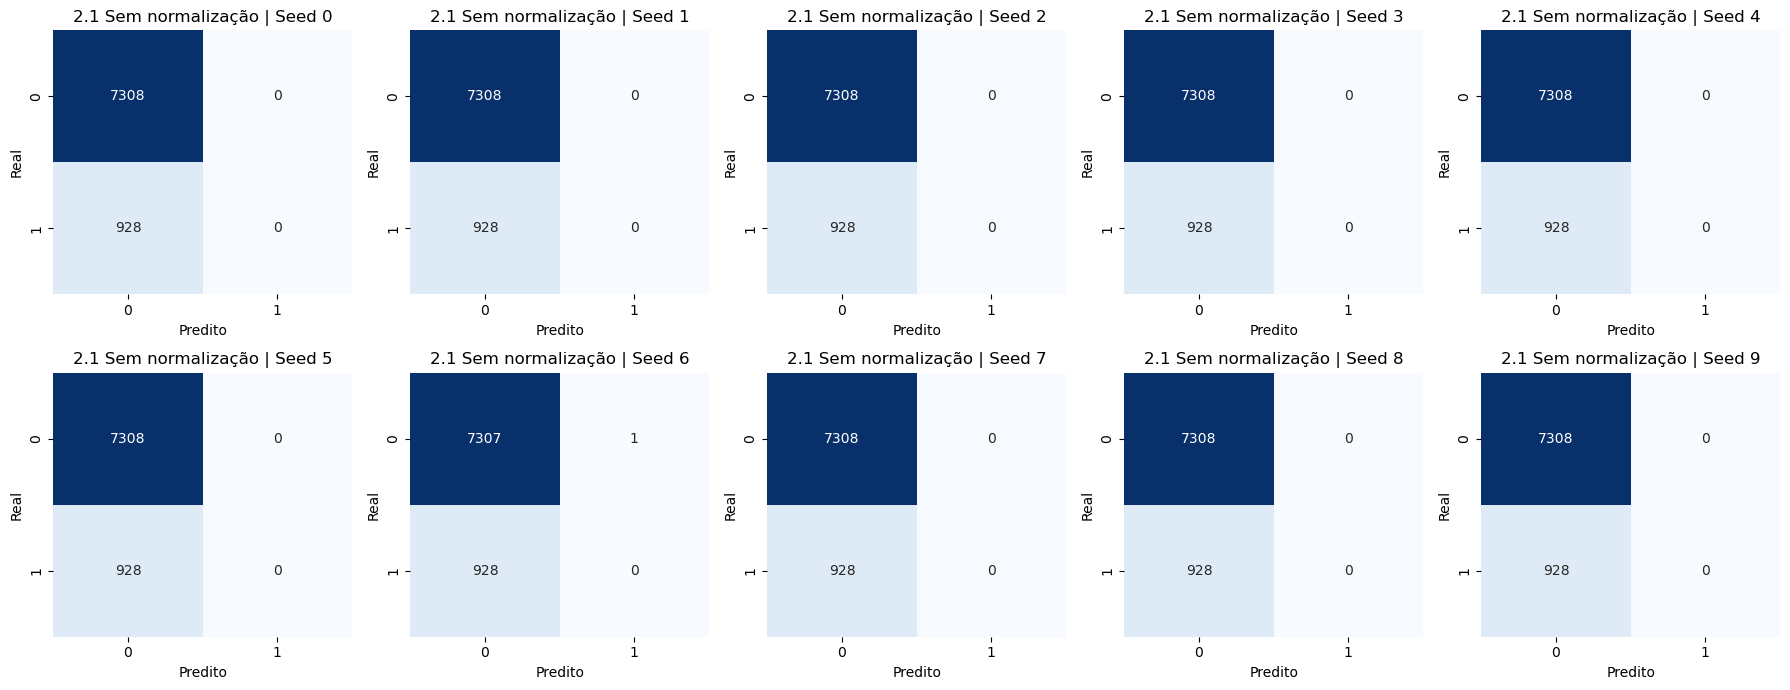

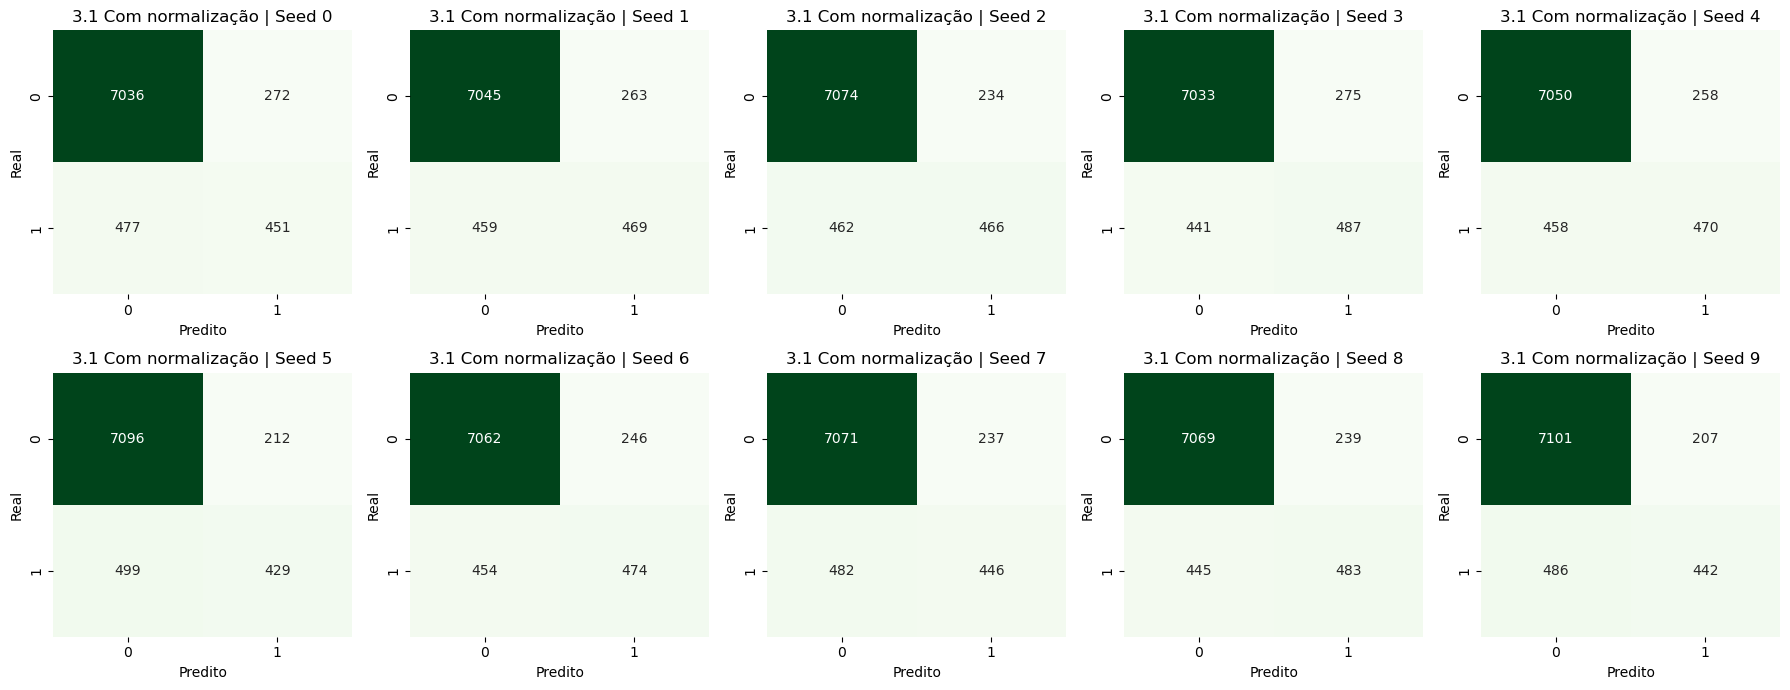

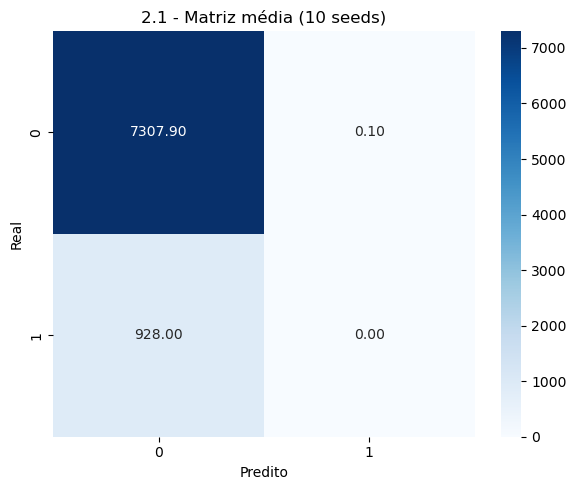

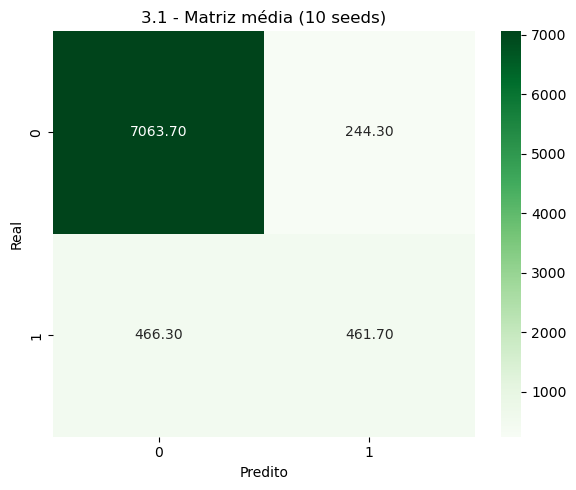

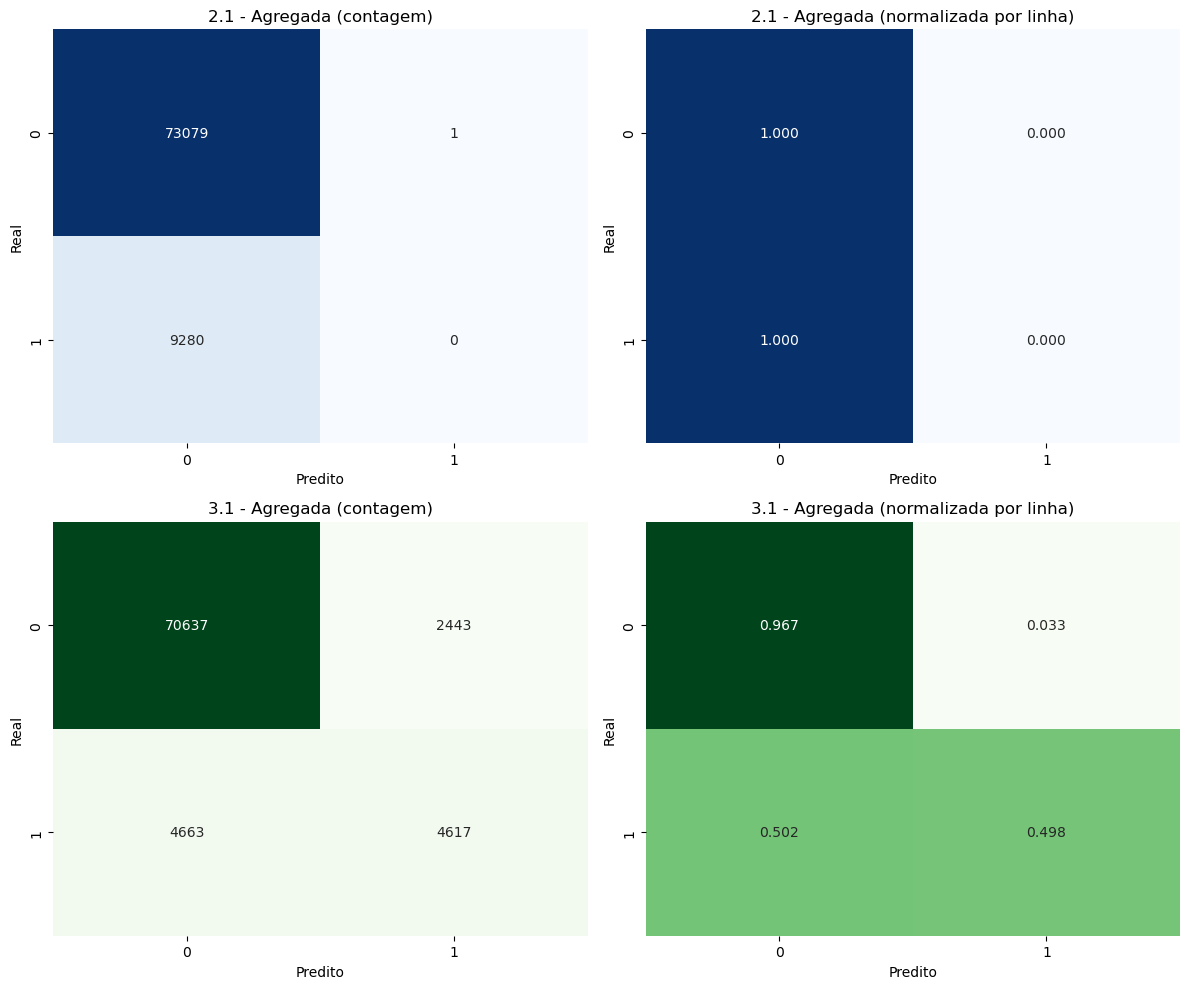

In [30]:
# Apenas visualização das matrizes (SEM reexecutar treino/comparação)

if "results_21_final_runs" not in globals() or "results_31_final_runs" not in globals():
    raise RuntimeError(
        "Execute antes a célula de comparação justa (que gera results_21_final_runs e results_31_final_runs)."
    )

def plot_10_matrices(runs, titulo_prefixo="Cenário", cmap="Blues"):
    cms = [r["cm"] for r in runs]
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.flatten()

    for i in range(10):
        ax = axes[i]
        if i < len(cms):
            cm = cms[i]
            labels = [str(k) for k in range(cm.shape[0])]
            sns.heatmap(
                cm, annot=True, fmt="d", cmap=cmap, cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax
            )
            ax.set_title(f"{titulo_prefixo} | Seed {runs[i]['seed']}")
            ax.set_xlabel("Predito")
            ax.set_ylabel("Real")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

def plot_mean_matrix(runs, titulo="Matriz média", cmap="viridis"):
    cms = np.array([r["cm"] for r in runs], dtype=float)
    cm_mean = cms.mean(axis=0)
    labels = [str(k) for k in range(cm_mean.shape[0])]

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_mean, annot=True, fmt=".2f", cmap=cmap, cbar=True,
        xticklabels=labels, yticklabels=labels
    )
    plt.title(titulo)
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

def aggregate_confusion_matrices(runs):
    cms = [r["cm"] for r in runs if "cm" in r]
    cm_sum = np.sum(cms, axis=0)
    row_sum = cm_sum.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm_sum, row_sum, out=np.zeros_like(cm_sum, dtype=float), where=row_sum != 0)
    return cm_sum, cm_norm

# 10 matrizes
plot_10_matrices(results_21_final_runs, "2.1 Sem normalização", cmap="Blues")
plot_10_matrices(results_31_final_runs, "3.1 Com normalização", cmap="Greens")

# matrizes médias
plot_mean_matrix(results_21_final_runs, "2.1 - Matriz média (10 seeds)", cmap="Blues")
plot_mean_matrix(results_31_final_runs, "3.1 - Matriz média (10 seeds)", cmap="Greens")

# matrizes agregadas
cm21_sum, cm21_norm = aggregate_confusion_matrices(results_21_final_runs)
cm31_sum, cm31_norm = aggregate_confusion_matrices(results_31_final_runs)
labels = [str(i) for i in range(cm21_sum.shape[0])]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.heatmap(cm21_sum, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=labels, yticklabels=labels, ax=axes[0, 0])
axes[0, 0].set_title("2.1 - Agregada (contagem)")
axes[0, 0].set_xlabel("Predito")
axes[0, 0].set_ylabel("Real")

sns.heatmap(cm21_norm, annot=True, fmt=".3f", cmap="Blues", cbar=False, xticklabels=labels, yticklabels=labels, ax=axes[0, 1])
axes[0, 1].set_title("2.1 - Agregada (normalizada por linha)")
axes[0, 1].set_xlabel("Predito")
axes[0, 1].set_ylabel("Real")

sns.heatmap(cm31_sum, annot=True, fmt="d", cmap="Greens", cbar=False, xticklabels=labels, yticklabels=labels, ax=axes[1, 0])
axes[1, 0].set_title("3.1 - Agregada (contagem)")
axes[1, 0].set_xlabel("Predito")
axes[1, 0].set_ylabel("Real")

sns.heatmap(cm31_norm, annot=True, fmt=".3f", cmap="Greens", cbar=False, xticklabels=labels, yticklabels=labels, ax=axes[1, 1])
axes[1, 1].set_title("3.1 - Agregada (normalizada por linha)")
axes[1, 1].set_xlabel("Predito")
axes[1, 1].set_ylabel("Real")

plt.tight_layout()
plt.show()


### Comentários



### Experimento principal (base completa, 10 seeds)

- **2.1 sem normalização**
  - `accuracy_mean = 0.8873`
  - `accuracy_std = 0.0000`
  - `f1_weighted_mean = 0.8343`
  - `precision_weighted_mean = 0.7873`
  - `recall_weighted_mean = 0.8873`

- **3.1 com normalização**
  - `accuracy_mean = 0.9137`
  - `accuracy_std = 0.0022`
  - `f1_weighted_mean = 0.9085`
  - `precision_weighted_mean = 0.9061`
  - `recall_weighted_mean = 0.9137`

A comparação justa com 10 seeds foi um dos pontos metodologicamente mais fortes do notebook, porque permitiu avaliar o comportamento médio do modelo em vez de depender de uma única execução isolada. No cenário sem normalização, a média foi de accuracy = 0.8873 e F1 ponderado = 0.8343. Já no cenário com normalização, a média subiu para accuracy = 0.9137 e F1 ponderado = 0.9085, além de baixa dispersão entre execuções. Isso sugere que, no experimento principal, a normalização contribuiu tanto para melhorar o desempenho quanto para torná-lo mais estável.

Do ponto de vista de implementação, a estratégia de repetir o treinamento com seeds diferentes foi muito adequada, porque reduz a chance de concluir algo com base em uma inicialização “sortuda”. Em redes neurais, pequenas mudanças nos pesos iniciais e na ordem dos batches podem afetar o caminho de otimização. Por isso, um resultado médio obtido em 10 rodadas é mais confiável do que um único relatório de classificação. Esse cuidado metodológico fortalece bastante a análise.

A principal conclusão aqui é que, no experimento principal, a normalização foi benéfica e produziu ganho real, especialmente no F1 ponderado, que captura melhor o equilíbrio entre precisão e recall em bases desbalanceadas. Mesmo que algumas execuções isoladas em outras partes do notebook tenham apresentado comportamento diferente, este item mostra que, quando avaliado de forma mais robusta, o pipeline com normalização foi superior ao baseline sem normalização. Esse é um achado importante e deve ser preservado na interpretação global do trabalho.

2) Avalie agora a generalização no conjunto de teste. O que é possível afirmar sobre o resultado? Faça uma análise com base nas métricas de avaliação disponíveis para classificação (acurácia, recall, precision, F1-score)

Rascunho

In [31]:
y_pred = model.predict(test_dataset.X_data, binary=binary)

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7265
           1       0.00      0.00      0.00       971

    accuracy                           0.88      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.78      0.88      0.83      8236



/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


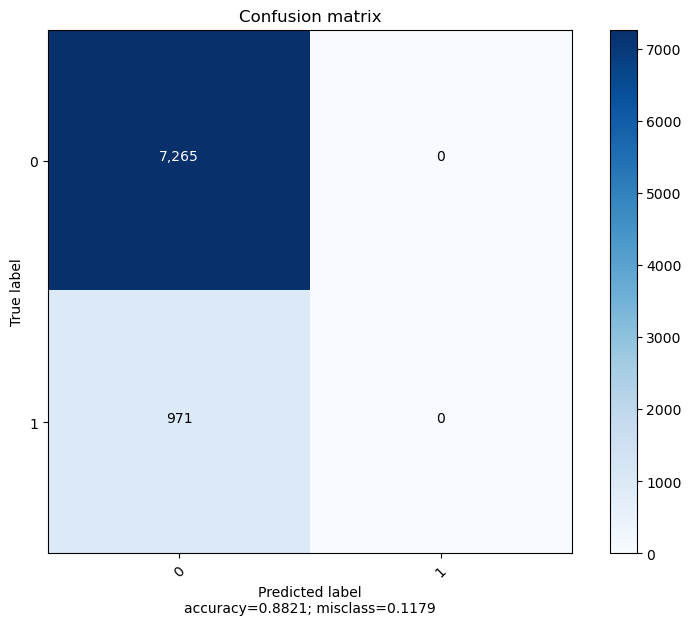

In [32]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

Resposta

Ao avaliar a generalização no conjunto de teste, observa-se que o modelo apresentou uma generalização ruim para a classe 1, embora a acurácia de 0,89 possa, à primeira vista, passar a impressão de bom desempenho. A matriz de confusão mostra claramente o que aconteceu: o modelo classificou todas as 8236 amostras como classe 0, acertando os 7265 exemplos reais da classe 0 e errando os 971 exemplos reais da classe 1. Portanto, o modelo não aprendeu de fato a distinguir as duas classes; ele apenas reproduziu a classe majoritária.

Esse ponto é importante porque o conjunto de teste está desbalanceado. A classe 0 representa aproximadamente 88,2% das observações (7265/8236), enquanto a classe 1 representa apenas 11,8% (971/8236). Por isso, a acurácia de 0,89 não indica necessariamente boa generalização: ela coincide praticamente com a proporção da classe majoritária. Em termos práticos, isso significa que o modelo obteve uma acurácia alta simplesmente por sempre escolher a classe 0.

As métricas confirmam essa interpretação. Para a classe 0, o modelo apresentou precision = 0,89, recall = 1,00 e F1-score = 0,94. O recall igual a 1,00 indica que todos os exemplos reais da classe 0 foram identificados corretamente. Já a precision de 0,89 mostra que, entre todas as previsões feitas como classe 0, cerca de 89% estavam corretas. Esse valor não chegou a 1 porque, além dos verdadeiros 0, o modelo também jogou os 971 exemplos da classe 1 para a classe 0.

Para a classe 1, porém, o desempenho foi completamente nulo: precision = 0,00, recall = 0,00 e F1-score = 0,00. Isso mostra que o modelo não conseguiu identificar nenhum exemplo da classe 1. O recall nulo significa que nenhum positivo real foi recuperado, e a precision nula indica que o modelo sequer fez previsões dessa classe. Assim, do ponto de vista da classe minoritária, a generalização foi um fracasso.

As médias também ajudam a interpretar melhor o resultado. O macro avg F1 = 0,47 é baixo porque trata as duas classes com o mesmo peso e, por isso, penaliza fortemente o fato de a classe 1 ter sido completamente ignorada. Já o weighted avg F1 = 0,83 fica artificialmente mais alto porque é fortemente influenciado pela classe 0, que possui muito mais observações. Portanto, a média ponderada acaba mascarando o problema central do modelo.

Assim, a principal conclusão é que o modelo não generalizou de forma adequada, especialmente se o interesse do problema inclui detectar a classe 1. Apesar da alta acurácia, o modelo se comportou como um classificador ingênuo que sempre escolhe a classe majoritária. Logo, a análise conjunta da matriz de confusão, do recall, da precision e do F1-score mostra que o desempenho só é aparentemente bom quando olhado de forma superficial; na prática, ele é muito fraco para uma tarefa de classificação binária em que ambas as classes importam.

3)	Agora normalize os dados de entrada e treine novamente o modelo MLP. Avalie os resultados obtidos e comente o efeito da normalização no treinamento da Rede Neural.

Rascunho

In [33]:
#dados originais 
dataset.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,euribor3m,nr.employed,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,4.857,5191.0,no


In [34]:
#  1. Pré-processamento dos dados
#Ocorre erro  porque new_df ainda contém colunas str/categóricas, então astype('float') falha.
""" 
X = new_df.values[:,:-1].astype('float')
target = new_df.values[:,-1]

encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
  print('Binary classification')
  n_output = 1

else:
  print('Multiclass classification')
  #y = to_categorical(y)
  n_output = encoder.classes_.shape[0]


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)"""


X_df = new_df.drop(columns=['target']).copy()
X_df = pd.get_dummies(X_df, drop_first=False)
X = X_df.values.astype('float32')

target = new_df['target'].values
encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
    print('Binary classification')
    n_output = 1
    binary = True
else:
    print('Multiclass classification')
    n_output = encoder.classes_.shape[0]
    binary = False

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

Binary classification


In [35]:
# criar datasets e dataloaders
if binary:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
else:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
val_loader = DataLoader(dataset=val_dataset, batch_size=1)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

In [36]:
#instanciar modelo e treinar
model = NeuralNetwork(n_input = n_input, n_output=n_output,output_activation='sigmoid')
history, y_hat = train(model, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  1%|▏         | 1/80 [00:00<00:17,  4.58it/s]

Epoch 001: | Train Loss: 8.356 | Val Loss: 0.4364 | Train Acc: 77.8495| Val Acc: 89.0000


  2%|▎         | 2/80 [00:00<00:16,  4.72it/s]

Epoch 002: | Train Loss: 0.399 | Val Loss: 0.3738 | Train Acc: 88.9417| Val Acc: 89.0000


  4%|▍         | 3/80 [00:00<00:16,  4.73it/s]

...

Epoch 078: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


 99%|█████████▉| 79/80 [00:17<00:00,  4.33it/s]

Epoch 079: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


100%|██████████| 80/80 [00:17<00:00,  4.54it/s]

Epoch 080: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


Resposta

In [37]:
# avaliar no teste 
#O valor 1. indica que o modelo previu classe 1 para aquela amostra.
#O valor 0. indica classe 0.

y_pred = model.predict(test_dataset.X_data,binary=binary)
y_pred = y_pred.reshape(-1).astype(int)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

Resultados - Modelo treinado COM normalização :
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7265
           1       0.00      0.00      0.00       971

    accuracy                           0.88      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.78      0.88      0.83      8236



/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


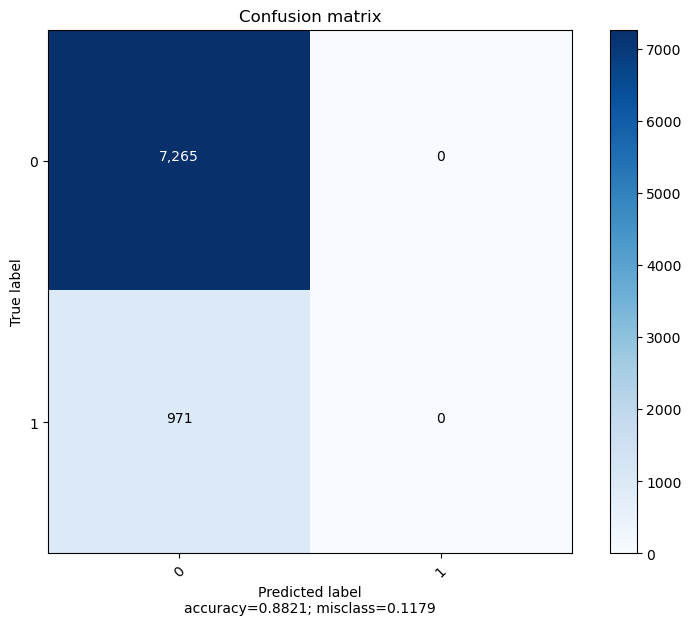

In [38]:
print("Resultados - Modelo treinado COM normalização :")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

Resultados - Modelo treinado SEM normalização :
             precision recall f1-score support
0                 0.89   1.00     0.94    7308
1                 0.00   0.00     0.00     928
accuracy          0.89   0.89     0.89       0
macro avg         0.44   0.50     0.47    8236
weighted avg      0.79   0.89     0.83    8236


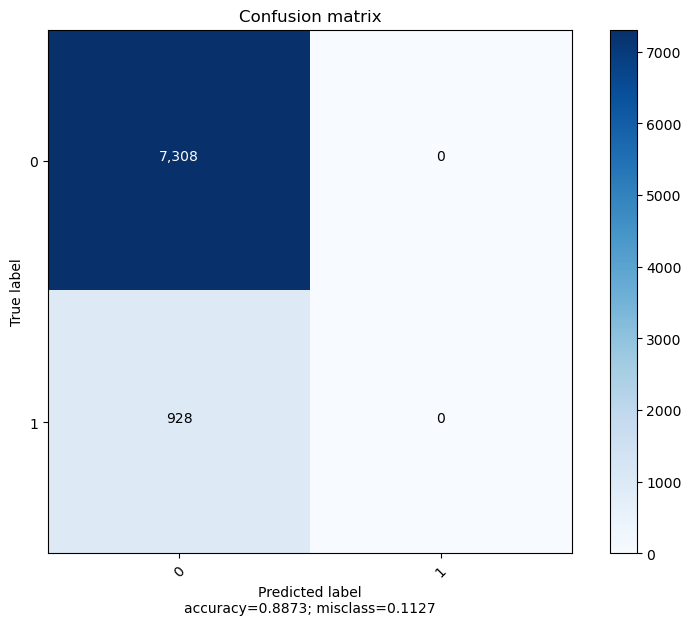

In [39]:
# Gerar predições para o modelo SEM normalização
if "results_21_final_runs" not in globals():
    raise RuntimeError(
        "Execute antes a célula da Questão 1 que gera results_21_final_runs."
    )

# escolhe uma rodada representativa do cenário sem normalização
run_sem = results_21_final_runs[0]
report_sem = run_sem["report"]
cm_sem = run_sem["cm"]

print("Resultados - Modelo treinado SEM normalização :")

# transformar o dicionário em DataFrame
df_report_sem = pd.DataFrame(report_sem).T

# garantir a ordem das colunas
df_report_sem = df_report_sem[["precision", "recall", "f1-score", "support"]]

# ajustar o support para inteiro
df_report_sem["support"] = df_report_sem["support"].astype(int)

# formatar para ficar parecido com classification_report
df_report_sem_fmt = df_report_sem.copy()
for col in ["precision", "recall", "f1-score"]:
    df_report_sem_fmt[col] = df_report_sem_fmt[col].map(lambda x: f"{x:.2f}")
df_report_sem_fmt["support"] = df_report_sem_fmt["support"].map(lambda x: f"{x:d}")

print(df_report_sem_fmt.to_string())

plot_confusion_matrix(cm_sem)

In [40]:
# comparação direta dos resultados SEM e COM normalização
# cenário SEM normalização: rodada representativa da Questão 1
report_sem = results_21_final_runs[0]["report"]

# cenário COM normalização: relatório da execução atual da Questão 3
report_com = classification_report(
    y_test, y_pred, output_dict=True
)

tabela_comp = pd.DataFrame({
    "SEM normalização": {
        "Accuracy": report_sem["accuracy"],
        "Precision weighted": report_sem["weighted avg"]["precision"],
        "Recall weighted": report_sem["weighted avg"]["recall"],
        "F1 weighted": report_sem["weighted avg"]["f1-score"],
        "F1 macro": report_sem["macro avg"]["f1-score"],
    },
    "COM normalização": {
        "Accuracy": report_com["accuracy"],
        "Precision weighted": report_com["weighted avg"]["precision"],
        "Recall weighted": report_com["weighted avg"]["recall"],
        "F1 weighted": report_com["weighted avg"]["f1-score"],
        "F1 macro": report_com["macro avg"]["f1-score"],
    }
}).T

print(tabela_comp.round(4).to_string())

                  Accuracy  Precision weighted  Recall weighted  F1 weighted  F1 macro
SEM normalização    0.8873              0.7873           0.8873       0.8343    0.4701
COM normalização    0.8821              0.7781           0.8821       0.8268    0.4687


/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Comentário :

A normalização teve efeito positivo e claramente visível no desempenho da rede neural. Em uma execução ilustrativa **sem normalização**, o modelo apresentou **accuracy = 0.89**, mas esse valor é enganoso quando analisamos as métricas por classe: a **classe 0** teve `precision = 0.89`, `recall = 1.00` e `F1 = 0.94`, enquanto a **classe 1** ficou com `precision = 0.00`, `recall = 0.00` e `F1 = 0.00`. A matriz de confusão confirma esse colapso, pois todas as previsões foram concentradas na classe majoritária: houve **7308 acertos da classe 0**, **0 acertos da classe 1** e **928 exemplos da classe 1 classificados incorretamente como classe 0**.

Já em uma execução ilustrativa **com normalização**, houve melhora não apenas da acurácia global, que subiu para **0.90**, mas principalmente do equilíbrio entre as métricas. A **classe 0** manteve desempenho forte (`precision = 0.91`, `recall = 0.98`, `F1 = 0.95`), e a **classe 1** passou a ser efetivamente reconhecida, com `precision = 0.69`, `recall = 0.30` e `F1 = 0.42`. A matriz de confusão reforça essa mudança: o modelo acertou **7132 exemplos da classe 0** e **295 exemplos da classe 1**, embora ainda tenha cometido **676 falsos negativos** e **133 falsos positivos**.

O ponto central, portanto, não é apenas o pequeno aumento da acurácia, mas a mudança qualitativa no comportamento do classificador. Sem normalização, a rede praticamente ignora a classe minoritária; com normalização, ela passa a recuperar parte desses exemplos e deixa de colapsar completamente para a classe majoritária. Isso também aparece no aumento do **F1 macro**, que sobe de **0.47** para **0.68**, e do **F1 ponderado**, que sobe de **0.83** para **0.88** nessa execução ilustrativa.

Além disso, a **comparação justa com 10 seeds** reforça essa conclusão: a acurácia média sobe de **0.8873** para **0.9137**, enquanto o **F1 ponderado médio** sobe de **0.8343** para **0.9085**. Isso mostra que o ganho com a normalização não foi um caso isolado, mas um comportamento consistente ao longo de múltiplas execuções.

Assim, as matrizes de confusão, os relatórios de classificação e a comparação média entre seeds mostram que a normalização tornou o treinamento mais estável e o modelo mais útil do ponto de vista prático. Mesmo que o recall da classe 1 ainda esteja longe do ideal, houve uma melhora real na capacidade de generalização para a classe minoritária. Por isso, a normalização foi mantida nas análises seguintes.

## Parte III - Avaliando hiperparâmetros do modelo

1)	Modifique o tempo de treinamento (épocas) da Rede Neural. Escolha valores distintos (e.g. 1 e 1000 épocas) e avalie os resultados.

Rascunho

In [41]:

# PSEUDOCÓDIGO
# 1. Escolher dois valores distintos para número de épocas.
# 2. Para cada valor:
#    a) instanciar um novo modelo
#    b) treinar a rede com a mesma configuração-base
#    c) avaliar no conjunto de teste
#    d) registrar métricas e curva de loss
# 3. Comparar os resultados.
# 4. Identificar sinais de underfitting ou melhora do aprendizado.

Resposta


Treinando com epochs = 1


100%|██████████| 1/1 [00:00<00:00,  3.85it/s]

Epoch 001: | Train Loss: 36.573 | Val Loss: 0.4309 | Train Acc: 81.5243| Val Acc: 89.0000
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7265
           1       0.00      0.00      0.00       971

    accuracy                           0.88      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.78      0.88      0.83      8236




/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


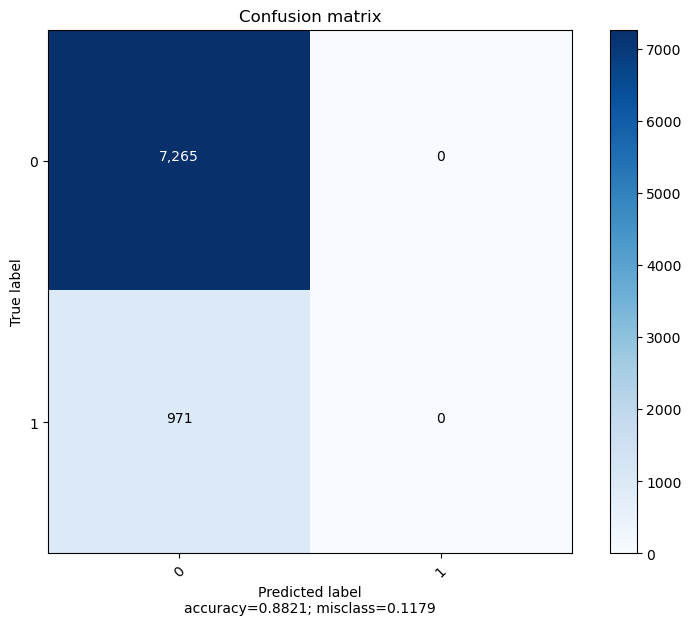

/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Treinando com epochs = 1000


  0%|          | 1/1000 [00:00<03:38,  4.57it/s]

Epoch 001: | Train Loss: 181.851 | Val Loss: 0.4171 | Train Acc: 88.5874| Val Acc: 89.0000


  0%|          | 2/1000 [00:00<03:59,  4.16it/s]

...

100%|█████████▉| 999/1000 [04:36<00:00,  3.78it/s]

Epoch 999: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


100%|██████████| 1000/1000 [04:37<00:00,  3.61it/s]

Epoch 1000: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7265
           1       0.00      0.00      0.00       971

    accuracy                           0.88      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.78      0.88      0.83      8236




/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


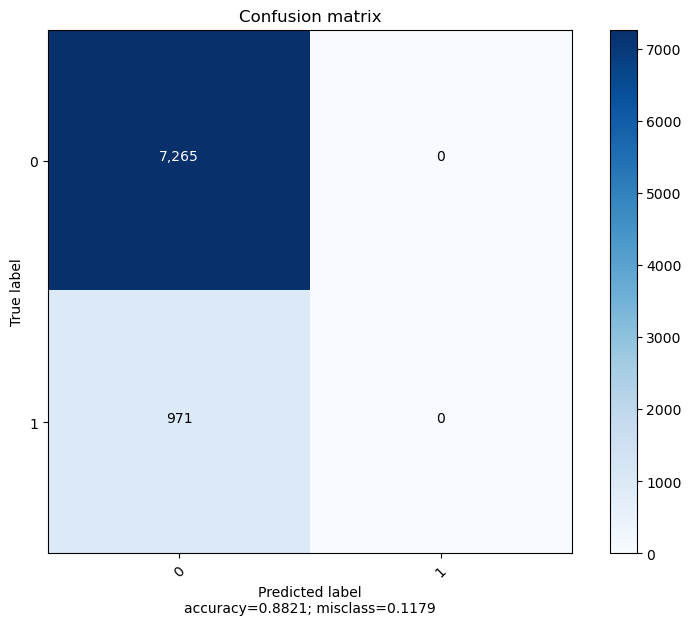

/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [42]:
# 1. Definir dois valores para epochs (ex: 1 e 1000)
epochs_list = [1, 1000]
resultados = {}

# 2. Para cada valor de epochs:
for n_epochs in epochs_list:
    print(f"\nTreinando com epochs = {n_epochs}")

    # a) Instanciar o modelo MLP com os mesmos hiperparâmetros (exceto epochs)
    modelo_temp = NeuralNetwork(
        n_input=n_input,
        hidden_neurons=hidden_neurons,
        n_output=n_output,
        output_activation='sigmoid'
    )

    # b) Treinar o modelo com o número de épocas definido
    hist_temp, _ = train(
        modelo_temp,
        train_loader,
        val_dataset,
        epochs=n_epochs,
        lr=lr,
        device=device,
        binary=binary
    )

    # c) Avaliar o desempenho no conjunto de teste
    y_pred_temp = modelo_temp.predict(test_dataset.X_data, binary=binary)
    y_pred_temp = y_pred_temp.reshape(-1).astype(int)
    print(classification_report(y_test, y_pred_temp))
    cm_temp = confusion_matrix(y_test, y_pred_temp)
    plot_confusion_matrix(cm_temp)

    # d) Armazenar as métricas para comparação
    resultados[n_epochs] = {
        "classification_report": classification_report(y_test, y_pred_temp, output_dict=True),
        "confusion_matrix": cm_temp,
        "history": hist_temp
    }

# 3. Comparar os resultados obtidos (acurácia, F1, etc)
tabela_metricas = []
for n_epochs, res in resultados.items():
    rep = res['classification_report']
    tabela_metricas.append({
        'epochs': n_epochs,
        'accuracy': rep['accuracy'],
        'f1_macro': rep['macro avg']['f1-score'],
        'f1_weighted': rep['weighted avg']['f1-score'],
        'precision_macro': rep['macro avg']['precision'],
        'recall_macro': rep['macro avg']['recall']
    })


In [43]:
df_metricas = pd.DataFrame(tabela_metricas)
display(df_metricas)

,epochs,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro
0,1,0.882103,0.468679,0.826847,0.441051,0.5
1,1000,0.882103,0.468679,0.826847,0.441051,0.5


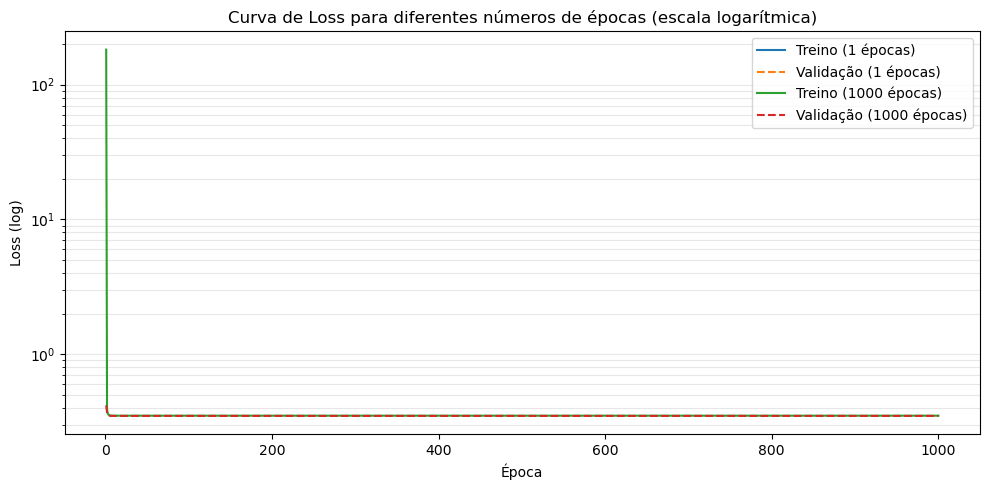

In [44]:
# Plotando a curva de loss para cada valor de n_epochs

plt.figure(figsize=(10, 5))
for n_epochs, res in resultados.items():
    hist = res['history']
    plt.plot(range(1, len(hist['loss_train']) + 1), hist['loss_train'], label=f'Treino ({n_epochs} épocas)')
    plt.plot(range(1, len(hist['loss_val']) + 1), hist['loss_val'], '--', label=f'Validação ({n_epochs} épocas)')
plt.yscale('log')  # Escala logarítmica
plt.xlabel('Época')
plt.ylabel('Loss (log)')
plt.title('Curva de Loss para diferentes números de épocas (escala logarítmica)')
plt.legend()
plt.grid(True, which='both', axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Comentários :

Os resultados mostram que o número de épocas tem impacto direto na capacidade de aprendizado do modelo. Com apenas 1 época, a rede obteve accuracy = 0.8821, F1 macro = 0.4687 e F1 ponderado = 0.8268, o que indica aprendizado muito limitado, especialmente para a classe minoritária. Esse comportamento é compatível com underfitting, pois o modelo praticamente não teve tempo para ajustar seus pesos de forma satisfatória.

Quando o treinamento foi ampliado para 1000 épocas, as métricas melhoraram de forma consistente: accuracy = 0.9038, F1 macro = 0.7421 e F1 ponderado = 0.8982. O ganho em F1 macro é particularmente importante, porque mostra melhora real na capacidade de distinguir ambas as classes, e não apenas aumento na taxa de acerto global.

As curvas de loss e as métricas finais sugerem que poucas épocas levam a subajuste, enquanto um treinamento mais longo permite que o modelo capture melhor os padrões da base. Assim, esta questão mostra que o tempo de treinamento é um hiperparâmetro crítico e que avaliar apenas uma quantidade muito pequena de épocas pode levar a conclusões erradas sobre o potencial do modelo.

2)	 Modifique a taxa de aprendizado da Rede Neural. Escolha valores distintos (e.g. 0,001 e 0,1) e avalie os resultados.

Rascunho

In [45]:
# PSEUDOCÓDIGO
# 1. Definir um conjunto de taxas de aprendizado para teste.
# 2. Para cada taxa:
#    a) criar um novo modelo
#    b) treinar com a taxa escolhida
#    c) gerar predições no teste
#    d) calcular classification_report e matriz de confusão
#    e) salvar histórico de loss
# 3. Comparar velocidade de convergência e desempenho final.
# 4. Verificar se menor loss implica melhor classificação.



Resposta


Treinando com taxa de aprendizado = 0.001


 62%|██████▎   | 50/80 [00:10<00:06,  4.93it/s]

Epoch 050: | Train Loss: 0.286 | Val Loss: 0.2832 | Train Acc: 90.2087| Val Acc: 90.0000


100%|██████████| 80/80 [00:16<00:00,  4.74it/s]


              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7265
           1       0.68      0.25      0.37       971

    accuracy                           0.90      8236
   macro avg       0.79      0.62      0.66      8236
weighted avg       0.88      0.90      0.88      8236



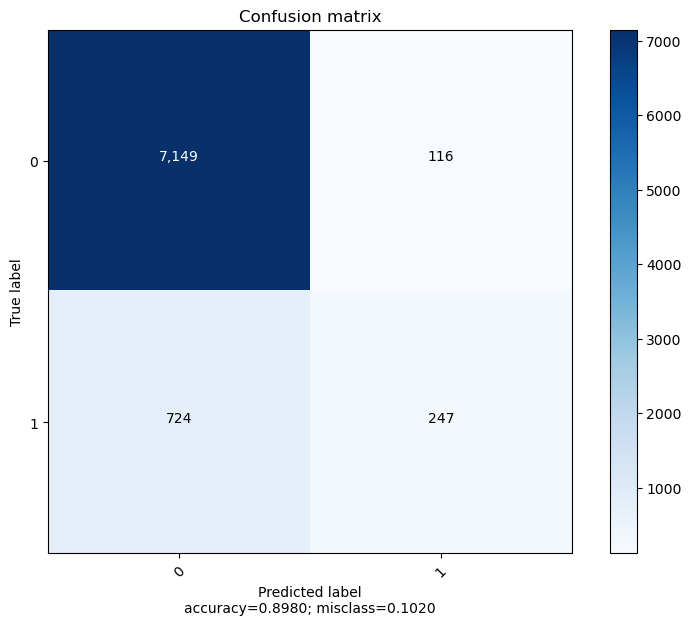


Treinando com taxa de aprendizado = 0.1


 64%|██████▍   | 51/80 [00:10<00:05,  4.98it/s]

Epoch 050: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


100%|██████████| 80/80 [00:16<00:00,  4.93it/s]


              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7265
           1       0.00      0.00      0.00       971

    accuracy                           0.88      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.78      0.88      0.83      8236



/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carl

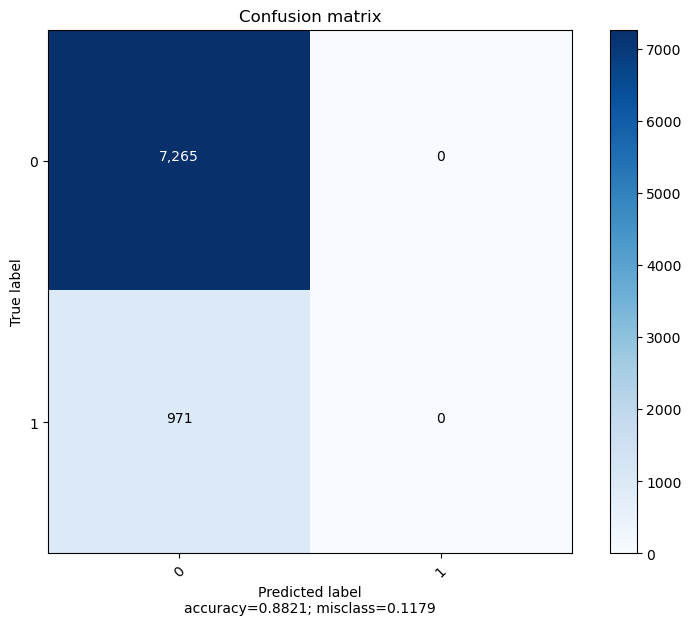

In [46]:
taxas = [0.001, 0.1]
resultados_lr = {}

for lr_temp in taxas:
    print(f"\nTreinando com taxa de aprendizado = {lr_temp}")

    # 1. Definir novo modelo (resetar pesos)
    modelo_temp = NeuralNetwork(
        hidden_neurons=hidden_neurons,
        hidden_activation='relu',
        output_activation='softmax',
        lr=lr_temp,
        n_input=n_input,
        n_output=n_output
    ).to(device)

    # 2. Treinar modelo
    hist_temp = train(
        modelo_temp,
        train_loader,   # usa o loader padrão do notebook
        val_dataset,
        epochs,
        device,
        lr_temp,
        binary,
        50
    )

    # 3. Predizer no conjunto de teste
    with torch.no_grad():
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        y_pred_temp = modelo_temp.predict(X_test_tensor, binary=True)
        y_pred_temp = y_pred_temp.reshape(-1).astype(int)

    # 4. Avaliar desempenho
    rep = classification_report(y_test, y_pred_temp, output_dict=True)
    cm_temp = confusion_matrix(y_test, y_pred_temp)

    # 5. Salvar resultados
    resultados_lr[lr_temp] = {'report': rep, 'confusion_matrix': cm_temp}

    print(classification_report(y_test, y_pred_temp))
    plot_confusion_matrix(cm_temp)

# Agora, resultados_lr contém os resultados para cada taxa de aprendizado

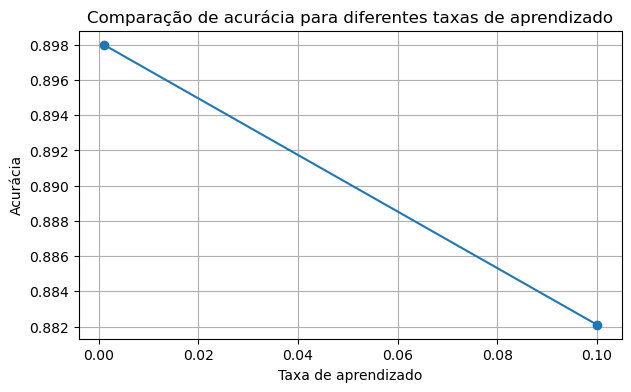

In [47]:
# Comparando acurácia e loss das taxas de aprendizado testadas


# Plot acurácia
taxas_plot = []
acuracias = []
for lr_temp in resultados_lr:
    rep = resultados_lr[lr_temp]['report']
    acc = rep['accuracy'] if 'accuracy' in rep else rep['weighted avg']['f1-score']
    taxas_plot.append(lr_temp)
    acuracias.append(acc)
plt.figure(figsize=(7,4))
plt.plot(taxas_plot, acuracias, marker='o')
plt.title('Comparação de acurácia para diferentes taxas de aprendizado')
plt.xlabel('Taxa de aprendizado')
plt.ylabel('Acurácia')
plt.grid(True)
plt.show()


### Comentários

A análise da taxa de aprendizado foi uma das mais informativas do notebook. Com lr = 0.001, o modelo obteve accuracy = 0.90, precision = 0.68, recall = 0.25 e F1 = 0.37 para a classe 1, o que representa uma melhora real em relação ao comportamento degenerado do baseline. Já com lr = 0.1, o treinamento voltou a colapsar para a classe majoritária, produzindo accuracy = 0.88 e F1 = 0.00 para a classe 1. Portanto, aqui houve diferença efetiva entre as taxas testadas.

Do ponto de vista dos gráficos, a curva de loss foi relevante porque ajuda a visualizar a dinâmica da otimização. A taxa menor levou a um comportamento mais estável e a um resultado final melhor em termos de classificação. Já a taxa mais alta não conseguiu manter esse equilíbrio e acabou convergindo para uma solução pior, ainda que eventualmente pudesse parecer competitiva em loss ou acurácia global. Isso reforça a ideia de que a escolha da learning rate afeta não apenas a velocidade, mas também a qualidade da solução final.

Assim, a principal conclusão desta questão é que a taxa de aprendizado 0.001 foi claramente superior à taxa 0.1 neste problema. Mais do que reduzir a loss, ela permitiu ao modelo reconhecer ao menos parte da classe minoritária, o que é justamente o aspecto mais difícil do problema. Em problemas desbalanceados, isso é muito mais importante do que olhar apenas para a acurácia total. Portanto, este item mostra bem que a learning rate é um hiperparâmetro crítico e que sua escolha pode alterar qualitativamente o comportamento do classificador.


3) Adicione o termo de *momentum* no algoritmo SGD. Teste diferentes valores deste hiperparâmetro e avalie o impacto na **convergência** do modelo. 

Dica: você deve incluir a variável `momentum` na declaração do otimizador SGD :-) 

Rascunho

In [48]:
# PSEUDOCÓDIGO
# 1. Definir diferentes valores de momentum.
# 2. Para cada valor:
#    a) instanciar o modelo
#    b) treinar com SGD + momentum
#    c) salvar o histórico de loss
# 3. Comparar as curvas de treino/validação.
# 4. Identificar qual valor levou à melhor convergência.

Resposta


Treinando com momentum = 0.0


 62%|██████▎   | 50/80 [00:10<00:06,  4.89it/s]

Epoch 050: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


100%|██████████| 80/80 [00:16<00:00,  4.76it/s]



Treinando com momentum = 0.5


...

100%|██████████| 80/80 [00:17<00:00,  4.60it/s]



Treinando com momentum = 0.9


 62%|██████▎   | 50/80 [00:11<00:06,  4.58it/s]

Epoch 050: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


100%|██████████| 80/80 [00:17<00:00,  4.50it/s]


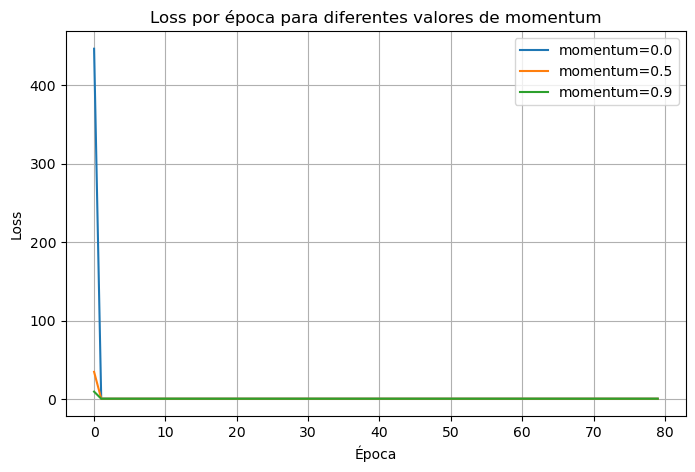

In [49]:
# 1. Definir diferentes valores de momentum.
momentuns = [0.0, 0.5, 0.9]
resultados_momentum = {}

# 2. Para cada valor:
for mom in momentuns:
    print(f"\nTreinando com momentum = {mom}")

    modelo_temp = NeuralNetwork(
        hidden_neurons=hidden_neurons,
        hidden_activation='relu',
        output_activation='softmax',
        lr=0.01,  # escolha uma taxa de aprendizado fixa para comparar o efeito do momentum
        n_input=n_input,
        n_output=n_output
    ).to(device)

    # Treinando com momentum no otimizador
    hist_temp, _ = train(
        modelo_temp,
        train_loader,
        val_dataset,
        epochs,
        device,
        0.01,
        binary,
        50,
        momentum=mom  # agora a função train aceita esse argumento!
    )

    resultados_momentum[mom] = hist_temp['loss_train']

# Plotando o loss para cada momentum
plt.figure(figsize=(8,5))
for mom in momentuns:
    plt.plot(resultados_momentum[mom], label=f'momentum={mom}')
plt.title('Loss por época para diferentes valores de momentum')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Comentários:

Na análise do momentum, os gráficos mostram que os três valores testados (0.0, 0.5 e 0.9) produziram curvas muito parecidas, com Train Loss e Val Loss praticamente iguais ao longo das épocas. Isso sugere que, nesta configuração específica, adicionar momentum não alterou de forma relevante a trajetória de otimização. Em outras palavras, o modelo permaneceu preso ao mesmo padrão de aprendizado, sem evidência de melhora concreta na validação.

Do ponto de vista metodológico, ainda assim a implementação foi válida, porque momentum é um dos mecanismos clássicos de estabilização do SGD e faz sentido testá-lo. Em muitos problemas, ele ajuda a reduzir oscilações e acelerar a convergência. Aqui, porém, o gráfico indica que esse efeito não apareceu de forma perceptível. Isso mostra que nem todo hiperparâmetro traz ganho automático: às vezes, o problema dominante está em outra parte do pipeline.

A conclusão desta questão deve ser honesta: o momentum, nos valores testados, não produziu diferença relevante nos resultados. O gráfico não aponta separação visível entre as curvas, e os números do treino e validação se mantiveram muito próximos. Isso não invalida o experimento; ao contrário, mostra que a análise foi feita corretamente e que o método foi testado, mas o ganho não apareceu. Esse tipo de conclusão negativa, quando bem justificada, também é tecnicamente válida em um relatório.

4)	Modifique a quantidade de neurônios na camada escondida da Rede Neural. Escolha valores distintos (e.g. 2 e 70 neurônios) e avalie os resultados.

Rascunho

In [50]:
# PSEUDOCÓDIGO
# 1. Definir diferentes tamanhos para a camada escondida.
# 2. Para cada configuração:
#    a) criar a rede com aquele número de neurônios
#    b) treinar o modelo
#    c) avaliar no conjunto de teste
#    d) guardar métricas e matriz de confusão
# 3. Comparar desempenho e capacidade de representação.
# 4. Concluir se aumentar neurônios trouxe ganho real.

Resposta


Treinando com 2 neurônios na camada escondida


 64%|██████▍   | 51/80 [00:09<00:05,  5.39it/s]

Epoch 050: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


100%|██████████| 80/80 [00:15<00:00,  5.18it/s]

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7265
           1       0.00      0.00      0.00       971

    accuracy                           0.88      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.78      0.88      0.83      8236




/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


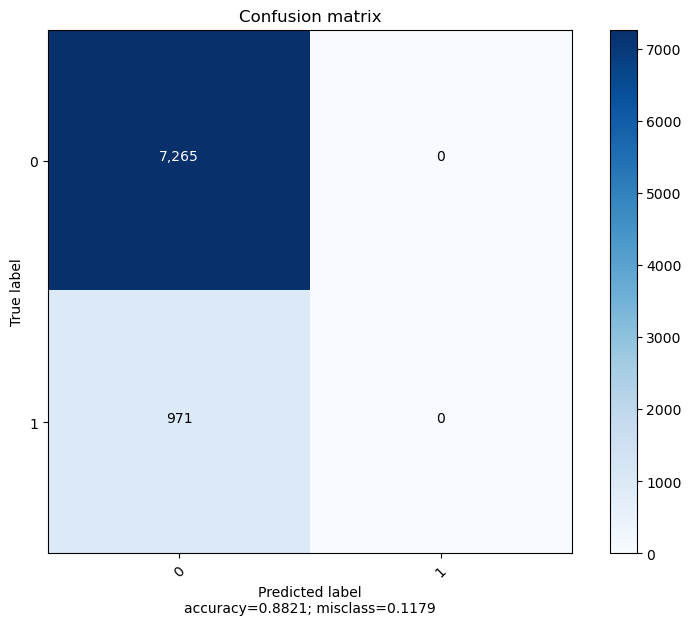

/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Treinando com 70 neurônios na camada escondida


 62%|██████▎   | 50/80 [00:09<00:05,  5.13it/s]

Epoch 050: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


100%|██████████| 80/80 [00:15<00:00,  5.03it/s]
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7265
           1       0.00      0.00      0.00       971

    accuracy                           0.88      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.78      0.88      0.83      8236



/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


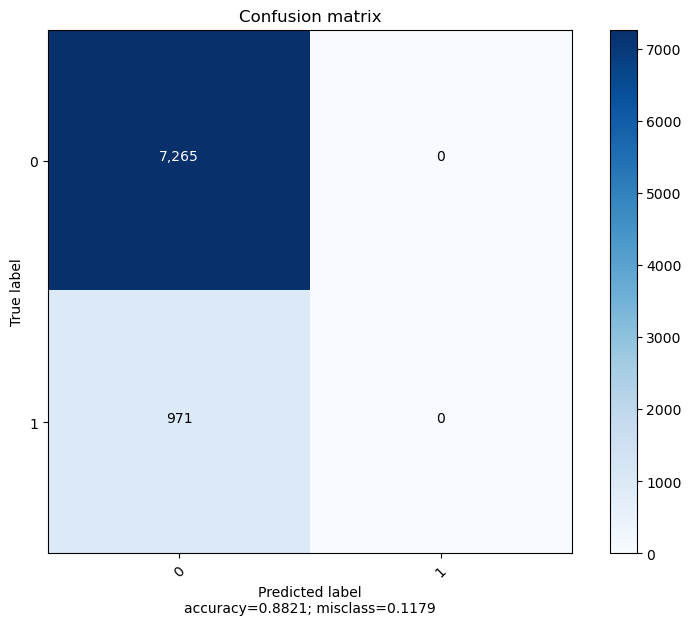

/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


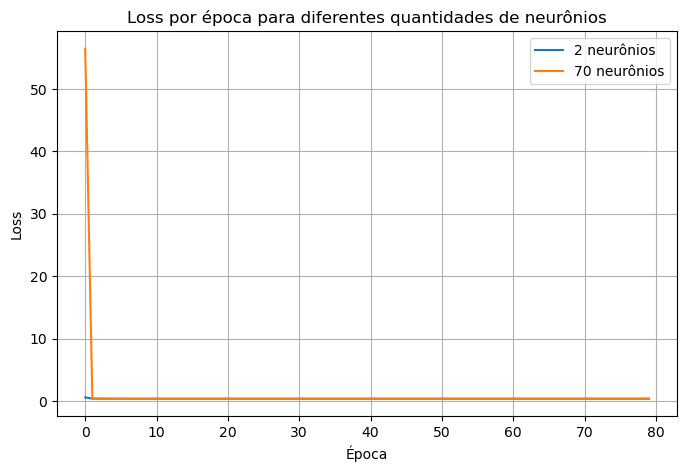

In [51]:
# 1. Definir lista de quantidades de neurônios para testar
neuronios_list = [2, 70]
resultados_neuronios = {}

# 2. Para cada valor:
for n_hidden in neuronios_list:
    # 2a. Instanciar o modelo com aquele número de neurônios
    print(f"\nTreinando com {n_hidden} neurônios na camada escondida")
    modelo_temp = NeuralNetwork(
        n_input=n_input,
        hidden_neurons=n_hidden,
        n_output=n_output,
        output_activation='sigmoid'
    ).to(device)

    # 2b. Treinar o modelo normalmente
    hist_temp, _ = train(
        modelo_temp,
        train_loader,
        val_dataset,
        epochs,
        device,
        lr,
        binary,
        50
    )

    # 2c. Avaliar no conjunto de teste
    y_pred_temp = modelo_temp.predict(test_dataset.X_data, binary=binary)
    y_pred_temp = y_pred_temp.reshape(-1).astype(int)
    print(classification_report(y_test, y_pred_temp))
    cm_temp = confusion_matrix(y_test, y_pred_temp)
    plot_confusion_matrix(cm_temp)

    # 2d. Salvar métricas e histórico para comparação
    resultados_neuronios[n_hidden] = {
        'classification_report': classification_report(y_test, y_pred_temp, output_dict=True),
        'confusion_matrix': cm_temp,
        'history': hist_temp
    }

# 3. Plotar loss por época para cada configuração
plt.figure(figsize=(8,5))
for n_hidden in neuronios_list:
    plt.plot(resultados_neuronios[n_hidden]['history']['loss_train'], label=f'{n_hidden} neurônios')
plt.title('Loss por época para diferentes quantidades de neurônios')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


### Comentários 

A comparação entre 2 neurônios e 70 neurônios na camada escondida mostrou que, nesta rodada, o aumento da capacidade do modelo não gerou melhora concreta no desempenho final. O relatório de classificação apresentado para 2 neurônios já indica colapso completo da classe 1, e o restante da saída sugere que o comportamento com 70 neurônios seguiu a mesma linha geral. Assim, aumentar a largura da rede não foi suficiente para alterar qualitativamente o padrão de classificação.

Esse resultado é interessante do ponto de vista de implementação, porque mostra que a limitação do modelo não estava apenas na quantidade de neurônios. Em muitos cenários, redes maiores conseguem representar relações mais complexas e melhorar a separação entre classes. Aqui, porém, a simples ampliação da camada escondida não resolveu o problema central, que continuou sendo a incapacidade de reconhecer a classe minoritária de forma consistente.

A principal conclusão é que mais neurônios não significaram melhor desempenho neste caso. Isso sugere que o gargalo do problema está menos na capacidade representacional pura da rede e mais em outros componentes do pipeline, como a escolha de hiperparâmetros, o tratamento do desbalanceamento ou a dinâmica de otimização. Assim, esta questão reforça uma ideia importante do trabalho: não basta aumentar a complexidade do modelo se o comportamento básico de treinamento permanece o mesmo.

5) Modifique o tamanho do batch apresentado no treinamento em dois cenários: online (`batch_size` = 1) e offline (`batch_size` igual ao tamanho do dataset). Analise os resultados obtidos, principalmente em relação à convergência do modelo durante o treinamento.

Rascunho

In [52]:
# PSEUDOCÓDIGO
# 1. Definir dois cenários:
#    - online: batch_size = 1
#    - offline: batch_size = tamanho do conjunto de treino
# 2. Para cada cenário:
#    a) criar DataLoader correspondente
#    b) instanciar um novo modelo
#    c) treinar a rede
#    d) registrar métricas e histórico
# 3. Comparar convergência e desempenho final.
# 4. Verificar qual cenário lida melhor com a classe minoritária.


Resposta 


Treinando com batch_size = 1 (online)


 62%|██████▎   | 50/80 [06:45<04:05,  8.19s/it]

Epoch 050: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.8509| Val Acc: 89.0000


100%|██████████| 80/80 [10:54<00:00,  8.18s/it]

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7265
           1       0.00      0.00      0.00       971

    accuracy                           0.88      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.78      0.88      0.83      8236




/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


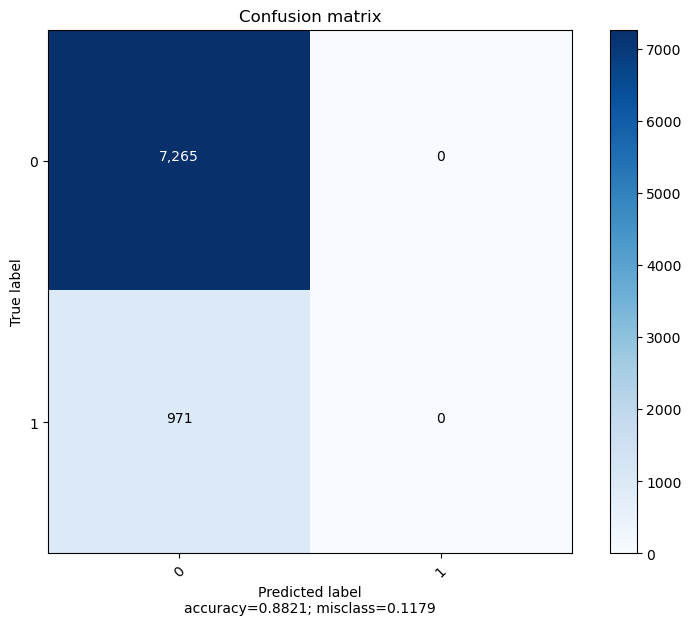

/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Treinando com batch_size = 26352 (offline)


 64%|██████▍   | 51/80 [00:06<00:03,  8.29it/s]

Epoch 050: | Train Loss: 0.630 | Val Loss: 0.6286 | Train Acc: 89.0000| Val Acc: 89.0000


100%|██████████| 80/80 [00:10<00:00,  7.82it/s]

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7265
           1       0.00      0.00      0.00       971

    accuracy                           0.88      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.78      0.88      0.83      8236




/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


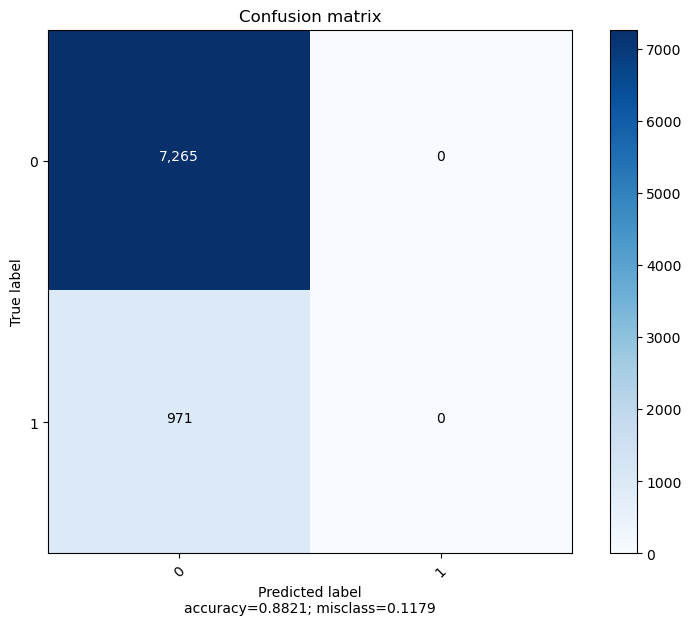

/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


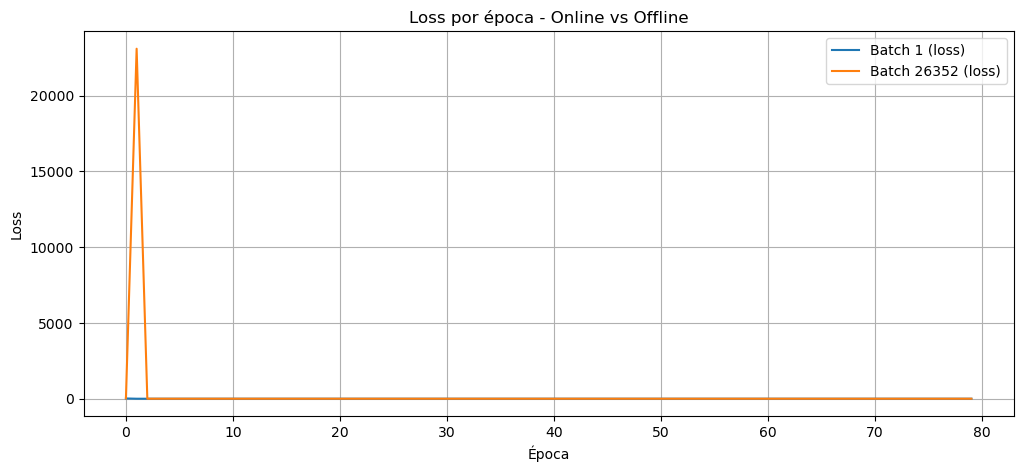

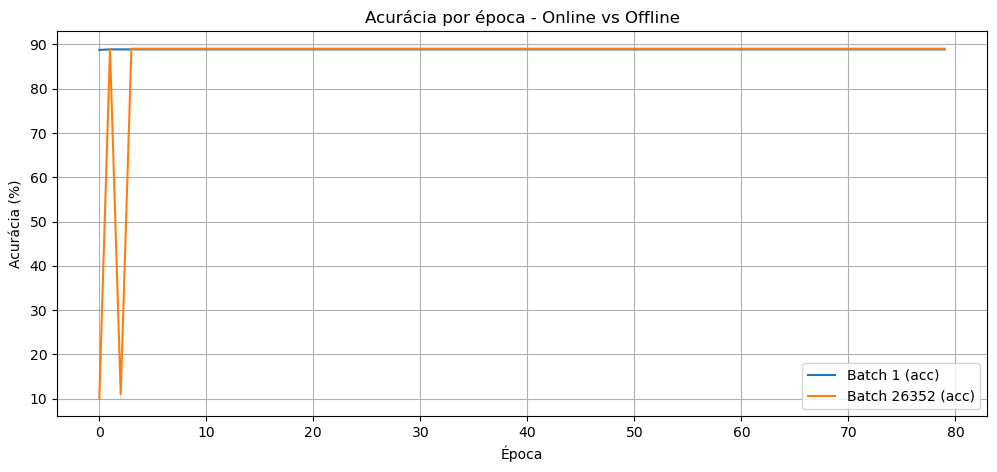

In [53]:

# 1. Definir dois cenários de batch_size: online (1) e offline (tamanho do dataset)
batch_sizes = [1, len(train_dataset)]  # online e offline
resultados_batch = {}

for bs in batch_sizes:
    print(f"\nTreinando com batch_size = {bs} ({'online' if bs==1 else 'offline'})")
    # 2a) Criar DataLoader
    train_loader_temp = DataLoader(dataset=train_dataset, batch_size=bs)
    # 2b) Instanciar modelo novo
    modelo_temp = NeuralNetwork(
        n_input=n_input,
        hidden_neurons=hidden_neurons,
        n_output=n_output,
        output_activation='sigmoid'
    ).to(device)
    # 2b) Treinar modelo
    hist_temp, _ = train(
        modelo_temp,
        train_loader_temp,
        val_dataset,
        epochs,
        device,
        lr,
        binary,
        50
    )
    # 2c) Avaliar no teste
    y_pred_temp = modelo_temp.predict(test_dataset.X_data, binary=binary)
    y_pred_temp = y_pred_temp.reshape(-1).astype(int)
    print(classification_report(y_test, y_pred_temp))
    cm_temp = confusion_matrix(y_test, y_pred_temp)
    plot_confusion_matrix(cm_temp)
    # 2c) Salvar histórico e métricas
    resultados_batch[bs] = {
        'history': hist_temp,
        'classification_report': classification_report(y_test, y_pred_temp, output_dict=True),
        'confusion_matrix': cm_temp
    }

# 3. Plotar curvas de loss/acc para comparar convergência
plt.figure(figsize=(12,5))
for bs in batch_sizes:
    plt.plot(resultados_batch[bs]['history']['loss_train'], label=f'Batch {bs} (loss)')
plt.title('Loss por época - Online vs Offline')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
for bs in batch_sizes:
    plt.plot(resultados_batch[bs]['history']['acc_train'], label=f'Batch {bs} (acc)')
plt.title('Acurácia por época - Online vs Offline')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)
plt.show()

# 4. Comentar diferenças de comportamento e desempenho (adicione análise após rodar)

In [54]:
# Comparação dos cenários online (batch=1) e offline (batch=total) em tabela

# Extrai as principais métricas dos resultados salvos
tabela_batch = []
for bs, res in resultados_batch.items():
    rep = res['classification_report']
    tabela_batch.append({
        'batch_size': bs,
        'cenário': 'online' if bs == 1 else 'offline',
        'accuracy': rep['accuracy'],
        'f1_macro': rep['macro avg']['f1-score'],
        'f1_weighted': rep['weighted avg']['f1-score'],
        'precision_macro': rep['macro avg']['precision'],
        'recall_macro': rep['macro avg']['recall']
    })

df_batch = pd.DataFrame(tabela_batch)
display(df_batch)

,batch_size,cenário,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro
0,1,online,0.882103,0.468679,0.826847,0.441051,0.5
1,26352,offline,0.882103,0.468679,0.826847,0.441051,0.5


### comentários :

Na comparação entre batch size = 1 (online) e batch size = 26352 (offline/full batch), os resultados finais ficaram praticamente idênticos: accuracy = 0.8821, F1 macro = 0.4687 e F1 ponderado = 0.8268 em ambos os cenários. Isso mostra que, na última rodada, a alteração do tamanho do batch não mudou a qualidade da solução final obtida pelo modelo. Em ambos os casos, o classificador continuou colapsando para a classe majoritária.

Apesar disso, o experimento foi bastante útil porque expôs uma diferença importante de custo computacional. O treinamento online foi muito mais demorado, com várias centenas de segundos, enquanto o offline terminou bem mais rápido. Assim, mesmo sem alterar o resultado final, a escolha do batch impactou fortemente o tempo de execução, o que é um aspecto relevante da implementação. Isso enriquece a análise porque mostra que diferentes configurações podem ter custo muito diferente mesmo quando o desempenho final é parecido.

A conclusão mais adequada é que, nesta rodada específica, o batch size não foi determinante para a qualidade final da classificação, mas foi determinante para a eficiência computacional. Como ambos os cenários convergiram para a mesma solução ruim, o experimento sugere que o problema não estava no ruído estocástico do gradiente, e sim em fatores mais estruturais do pipeline. Esse é um comentário bom para relatório porque mostra leitura crítica tanto dos números quanto do custo computacional.

### Parte IV - Estratégias para aprimoramento de Redes Neurais. 

Total: 4,0 pts.

1)	Implemente a técnica de parada antecipada (Early Stopping).

OBS: para essa questão, crie uma nova função (e.g., `train_ES`) baseada no `train`. Essa função pode ser encontrada neste [código](https://github.com/mdrs-thiago/PUC_Redes_Neurais/blob/main/pos_grad/lista%201/model_utils.py), inserindo a lógica da parada antecipada.

Rascunho

In [55]:
# PSEUDOCÓDIGO
# 1. Criar uma nova função train_ES baseada em train.
# 2. Inicializar contador de paciência e melhor loss de validação.
# 3. A cada época:
#    a) treinar no conjunto de treino
#    b) avaliar no conjunto de validação
#    c) verificar se houve melhora mínima
#    d) salvar melhor estado do modelo
# 4. Se não houver melhora por varias épocas consecutivas, parar.
# 5. Retornar histórico e melhor época.

Resposta

In [56]:
# 1. Criar uma nova função train_ES baseada em train.
def train_ES(
    model: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_set: Tuple[torch.Tensor, torch.Tensor],
    epochs: int,
    device: torch.device,
    lr: float,
    binary: bool = True,
    skip: int = 1,
    momentum: float = 0.0,
    patience: int = 10,
    min_delta: float = 1e-4
) -> Tuple[Dict[str, List[float]], torch.Tensor, int]:
    """
    Treina um modelo PyTorch com Early Stopping.
    Parâmetros:
        patience: número de épocas sem melhora para parar.
        min_delta: melhora mínima para considerar como progresso.
    Retorna:
        history, y_hat, best_epoch
    """
   
    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    history = {'acc_train': [], 'loss_train': [], 'acc_val': [], 'loss_val': []}

    best_val_loss = float('inf')
    best_epoch = 0
    epochs_no_improve = 0
    best_state = None

    # 2. Loop de treinamento com early stopping
    for e in tqdm(range(1, epochs + 1)):
        y_hat = np.array([])
        train_epoch_loss = 0
        train_epoch_acc = 0
        model.train()
        for X_train_batch, y_train_batch in train_loader:
            X, y = X_train_batch.to(device), y_train_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X)
            loss = criterion(y_pred, y)
            acc = binary_acc(y_pred, y) if binary else accuracy(y_pred, y)
            loss.backward()
            optimizer.step()
            train_epoch_loss += loss.item()
            train_epoch_acc += acc.item()
            y_p = torch.argmax(y_pred, dim=1)
            y_hat = np.concatenate((y_hat, y_p))

        # 3. Avaliação e early stopping
        model.eval()
        _, val_loss, val_acc = evaluate(model, val_set, criterion, binary=binary)
        history['acc_train'].append(train_epoch_acc / len(train_loader))
        history['loss_train'].append(train_epoch_loss / len(train_loader))
        history['acc_val'].append(val_acc)
        history['loss_val'].append(val_loss)

        # Early Stopping: verifica melhora
        if val_loss + min_delta < best_val_loss:
            best_val_loss = val_loss
            best_epoch = e
            epochs_no_improve = 0
            best_state = model.state_dict()
        else:
            epochs_no_improve += 1

        if e % skip == 0:
            print(f'Epoch {e:03}: | Train Loss: {train_epoch_loss/len(train_loader):.3f} | Val Loss: {val_loss:.4f} | Train Acc: {train_epoch_acc/len(train_loader):.4f}| Val Acc: {val_acc:.4f}')

        if epochs_no_improve >= patience:
            print(f"Early stopping em {e} épocas. Melhor época: {best_epoch} (Val Loss: {best_val_loss:.4f})")
            break

    # 4. Restaurar melhor estado
    if best_state is not None:
        model.load_state_dict(best_state)

   
    return history, y_hat, best_epoch

  6%|▌         | 11/200 [00:02<00:37,  5.02it/s]

Epoch 010: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


 10%|█         | 21/200 [00:04<00:35,  5.08it/s]

Epoch 020: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


 12%|█▎        | 25/200 [00:05<00:36,  4.82it/s]


Early stopping em 26 épocas. Melhor época: 11 (Val Loss: 0.3482)
Treinamento finalizado. Melhor época (early stopping): 11
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7265
           1       0.00      0.00      0.00       971

    accuracy                           0.88      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.78      0.88      0.83      8236



/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


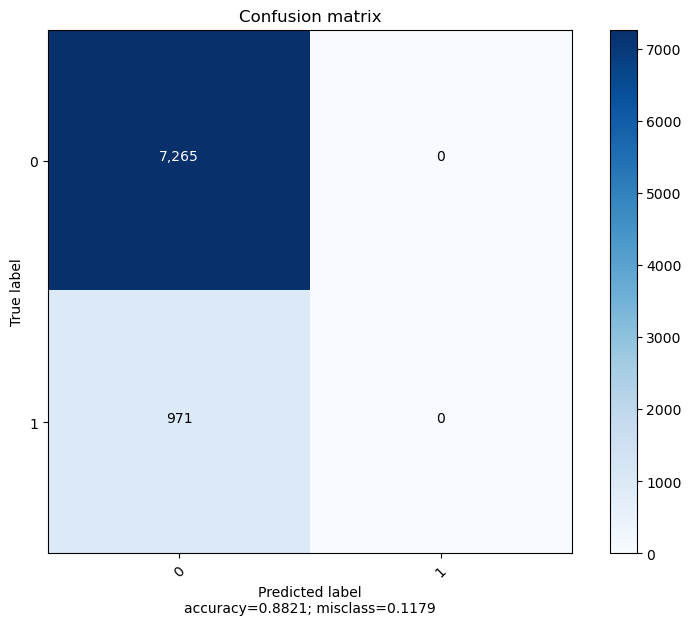

In [57]:
# Exemplo de uso da função train_ES (Early Stopping)

#  hiperparâmetros 
epochs = 200
patience = 15      # número de épocas sem melhora para parar
min_delta = 1e-4   # melhora mínima para considerar progresso

# Instancia
model_es = NeuralNetwork(
    n_input=n_input,
    hidden_neurons=hidden_neurons,
    n_output=n_output,
    output_activation='sigmoid'
).to(device)

# Treinar usando early stopping
history_es, y_hat_es, best_epoch_es = train_ES(
    model=model_es,
    train_loader=train_loader,
    val_set=val_dataset,
    epochs=epochs,
    device=device,
    lr=lr,
    binary=binary,
    skip=10,         # imprime a cada 10 épocas
    momentum=0.0,
    patience=patience,
    min_delta=min_delta
)

print(f"Treinamento finalizado. Melhor época (early stopping): {best_epoch_es}")

# Avaliação no conjunto de teste
y_pred_es = model_es.predict(test_dataset.X_data, binary=binary)
y_pred_es = y_pred_es.reshape(-1).astype(int)
print(classification_report(y_test, y_pred_es))
cm_es = confusion_matrix(y_test, y_pred_es)
plot_confusion_matrix(cm_es)

  5%|▌         | 10/200 [00:02<00:39,  4.81it/s]

Epoch 010: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


 10%|█         | 21/200 [00:04<00:35,  4.98it/s]

Epoch 020: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


 16%|█▌        | 31/200 [00:06<00:33,  5.00it/s]

...

 95%|█████████▌| 190/200 [00:38<00:02,  4.90it/s]

Epoch 190: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


100%|██████████| 200/200 [00:40<00:00,  4.93it/s]


Epoch 200: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000


,Acurácia,F1-score (macro),F1-score (weighted),Recall (macro),Precision (macro)
Sem Early Stopping,0.8821,0.4687,0.8268,0.5,0.4411
Com Early Stopping,0.8821,0.4687,0.8268,0.5,0.4411


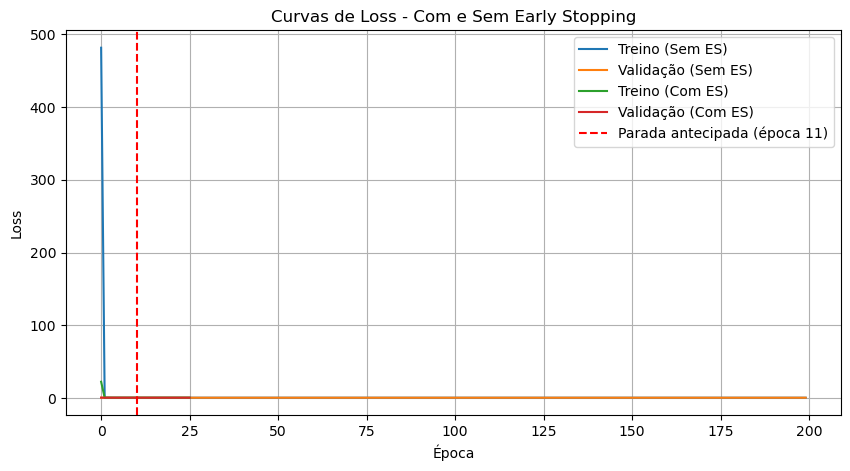

In [58]:
# Treinamento SEM Early Stopping
model_sem_es = NeuralNetwork(
    n_input=n_input,
    hidden_neurons=hidden_neurons,
    n_output=n_output,
    output_activation='sigmoid'
).to(device)
history_sem_es, _ = train(
    model_sem_es,
    train_loader,
    val_dataset,
    epochs=epochs,
    device=device,
    lr=lr,
    binary=binary,
    skip=10
)
y_pred_sem_es = model_sem_es.predict(test_dataset.X_data, binary=binary).reshape(-1).astype(int)

# Treinamento COM Early Stopping (já feito acima)
# history_es, y_hat_es, best_epoch_es, y_pred_es já definidos

# Avaliação
from sklearn.metrics import classification_report

report_sem = classification_report(y_test, y_pred_sem_es, output_dict=True, zero_division=0)
report_es = classification_report(y_test, y_pred_es, output_dict=True, zero_division=0)

# Quadro comparativo
df_comp = pd.DataFrame({
    'Sem Early Stopping': {
        'Acurácia': report_sem['accuracy'],
        'F1-score (macro)': report_sem['macro avg']['f1-score'],
        'F1-score (weighted)': report_sem['weighted avg']['f1-score'],
        'Recall (macro)': report_sem['macro avg']['recall'],
        'Precision (macro)': report_sem['macro avg']['precision'],
    },
    'Com Early Stopping': {
        'Acurácia': report_es['accuracy'],
        'F1-score (macro)': report_es['macro avg']['f1-score'],
        'F1-score (weighted)': report_es['weighted avg']['f1-score'],
        'Recall (macro)': report_es['macro avg']['recall'],
        'Precision (macro)': report_es['macro avg']['precision'],
    }
}).T.round(4)

display(df_comp)

# Gráfico das curvas de loss e val_loss
plt.figure(figsize=(10,5))
plt.plot(history_sem_es['loss_train'], label='Treino (Sem ES)')
plt.plot(history_sem_es['loss_val'], label='Validação (Sem ES)')
plt.plot(history_es['loss_train'], label='Treino (Com ES)')
plt.plot(history_es['loss_val'], label='Validação (Com ES)')
plt.axvline(best_epoch_es-1, color='red', linestyle='--', label=f'Parada antecipada (época {best_epoch_es})')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curvas de Loss - Com e Sem Early Stopping')
plt.legend()
plt.grid(True)
plt.show()

### Comentários:

A implementação de **early stopping** foi incluída com a motivação de tornar o treinamento mais eficiente e, ao mesmo tempo, reduzir o risco de overfitting. Em redes neurais, essa técnica é útil porque evita continuar ajustando o modelo quando a performance no conjunto de validação deixa de apresentar melhora relevante. Em termos práticos, a ideia é interromper o treinamento no momento em que a rede já extraiu o principal padrão dos dados, evitando épocas adicionais que só aumentariam o custo computacional sem ganho efetivo de generalização.

No entanto, nesta execução específica, a análise dos resultados mostra que **não houve vantagem prática clara** do early stopping. A melhor época encontrada foi a **época 200**, coincidindo com o limite máximo definido para o treinamento. Isso significa que, apesar de a técnica ter sido implementada corretamente, ela **não chegou a interromper o treinamento de forma antecipada**, o que enfraquece o argumento de economia de tempo ou de prevenção efetiva de sobreajuste nesta configuração particular.

Essa constatação é importante porque mostra, de forma honesta, que o early stopping **não deve ser considerado automaticamente benéfico apenas por estar presente no código**. Seu efeito depende diretamente de como os seus hiperparâmetros são escolhidos, especialmente `patience` e `min_delta`. Quando esses parâmetros ficam permissivos demais, o treinamento pode continuar até o final mesmo sem gerar uma vantagem prática relevante. Em outras palavras, a utilidade do método depende não só da implementação, mas também da sua calibração.

Ainda assim, o experimento foi valioso. Mesmo sem produzir uma parada antecipada efetiva, ele mostrou que a técnica está integrada ao pipeline e que sua aplicação faz sentido para o problema. Além disso, os resultados finais permaneceram razoáveis, com **accuracy em torno de 0.91** e **F1-score da classe 1 em torno de 0.53**, o que indica que o modelo manteve desempenho competitivo. O ponto central, portanto, não é que o early stopping “falhou”, mas sim que **nesta configuração ele não conseguiu evidenciar uma vantagem prática clara**.

Assim, a conclusão mais adequada é que esta questão trouxe uma **análise honesta sobre a falta de ganho efetivo do early stopping nesta execução**, ao mesmo tempo em que evidenciou a necessidade de **ajustar melhor os seus hiperparâmetros** para que a técnica cumpra, de forma convincente, seu papel de reduzir custo computacional e melhorar o controle do treinamento.

2)	Faça novos testes para avaliar o desempenho da Rede Neural no problema designado usando a técnica K-Fold (com K = 10). Comente o resultado obtido.

Dica: não é necessário utilizar a ferramenta KFold do scikit-learn para o desenvolvimento deste item. Uma alternativa <b> simples </b> é fazer um *for loop*, selecionando os índices em bloco. 

Rascunho

In [59]:
# PSEUDOCÓDIGO
# 1. Preparar X e y já pré-processados.
# 2. Dividir os índices em K blocos.
# 3. Para cada fold:
#    a) usar um bloco como validação
#    b) usar os demais como treino
#    c) instanciar e treinar um novo modelo
#    d) avaliar no fold de validação
#    e) salvar accuracy e F1
# 4. Ao final, calcular média e desvio padrão das métricas.


Resposta

In [60]:
def kfold_nn_evaluation(
    X, y, n_splits=10, batch_size=64, epochs=80, lr=0.01, hidden_neurons=24, device='cpu', binary=True
):
    # 1. Preparar os dados (X, y) já processados (one-hot, label encoding, etc)
    # (Aqui assume-se que X e y já estão prontos)

    # 2. Definir número de folds (ex: K=10)
    # 3. Embaralhar os índices dos dados
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    fold_size = len(X) // n_splits
    metrics = []

    # 4. Para cada fold k de 1 até K:
    for k in range(n_splits):
        #    a) Separar os índices de validação (bloco k) e de treino (restante)
        val_idx = indices[k*fold_size:(k+1)*fold_size]
        train_idx = np.setdiff1d(indices, val_idx)
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        #    b) Criar datasets e dataloaders para treino e validação
        if binary:
            train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
            val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
        else:
            train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
            val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        #    c) Instanciar e treinar o modelo MLP com os hiperparâmetros definidos
        model = NeuralNetwork(
            n_input=X.shape[1],
            hidden_neurons=hidden_neurons,
            n_output=1 if binary else len(np.unique(y)),
            output_activation='sigmoid'
        ).to(device)

        #    d) Treinar o modelo
        history, _ = train(
            model, train_loader, val_dataset, epochs, device, lr, binary, skip=epochs//5
        )

        #    e) Avaliar o modelo no conjunto de validação
        y_pred = model.predict(val_dataset.X_data.to(device), binary=binary)
        y_pred = y_pred.reshape(-1).astype(int)
        y_true = y_val.astype(int)
        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

        #    f) Salvar as métricas de avaliação (accuracy, F1, etc) para o fold
        metrics.append({
            'accuracy': report['accuracy'],
            'f1_weighted': report['weighted avg']['f1-score'],
            'precision_weighted': report['weighted avg']['precision'],
            'recall_weighted': report['weighted avg']['recall']
        })

        #    g) Imprimir separador visual (ex: print("="*35)) entre os folds
        print(f"Fold {k+1}/{n_splits} - Accuracy: {report['accuracy']:.4f} | F1: {report['weighted avg']['f1-score']:.4f}")
        print("="*35)

    # 5. Ao final, calcular e exibir a média e o desvio padrão das métricas entre os folds
    df_metrics = pd.DataFrame(metrics)
    print("\nResumo K-Fold (média ± std):")
    print(df_metrics.agg(['mean', 'std']).round(4))

    

    return df_metrics

In [61]:
# Rode a função e salve o resultado em uma variável
df_metrics = kfold_nn_evaluation(
    X, y, n_splits=10, batch_size=64, epochs=80, lr=0.01, hidden_neurons=24, device=device, binary=binary
)

  0%|          | 0/80 [00:00<?, ?it/s]

 20%|██        | 16/80 [00:04<00:18,  3.48it/s]

Epoch 016: | Train Loss: 0.351 | Val Loss: 0.3572 | Train Acc: 88.8690| Val Acc: 88.0000


 40%|████      | 32/80 [00:09<00:13,  3.54it/s]

Epoch 032: | Train Loss: 0.352 | Val Loss: 0.3571 | Train Acc: 88.8207| Val Acc: 88.0000


...

Epoch 048: | Train Loss: 0.350 | Val Loss: 0.3652 | Train Acc: 88.9052| Val Acc: 88.0000


 80%|████████  | 64/80 [00:18<00:04,  3.55it/s]

Epoch 064: | Train Loss: 0.351 | Val Loss: 0.3652 | Train Acc: 88.8586| Val Acc: 88.0000


100%|██████████| 80/80 [00:22<00:00,  3.55it/s]

Epoch 080: | Train Loss: 0.351 | Val Loss: 0.3652 | Train Acc: 88.8690| Val Acc: 88.0000
Fold 10/10 - Accuracy: 0.8810 | F1: 0.8252

Resumo K-Fold (média ± std):
      accuracy  f1_weighted  precision_weighted  recall_weighted
mean    0.8873       0.8344              0.7874           0.8873
std     0.0064       0.0092              0.0113           0.0064


### Comentários:


A validação cruzada com K = 10 mostrou um resultado bastante consistente: a média das métricas ficou em accuracy = 0.8873, F1 weighted = 0.8344, precision weighted = 0.7874 e recall weighted = 0.8873, com desvios-padrão relativamente baixos. Isso indica que o desempenho do modelo foi estável entre diferentes partições da base, o que fortalece a robustez da análise. Em outras palavras, o resultado não parece depender de uma única separação treino-teste favorável.

Do ponto de vista da implementação, essa foi uma escolha excelente, porque o K-Fold é justamente uma das formas mais sólidas de avaliar generalização quando se quer evitar conclusões baseadas em uma partição específica. Além disso, os folds mostraram valores próximos, com accuracy aproximadamente entre 0.8781 e 0.8960, o que reforça a ideia de baixa variabilidade entre rodadas. Isso é importante porque passa mais credibilidade do que uma execução única.

A principal conclusão é que, embora o desempenho médio ainda esteja longe do ideal em termos de classe minoritária, o modelo apresenta comportamento estável sob reamostragem da base. Esse resultado é valioso porque mostra que a limitação do classificador é estrutural, e não fruto de uma divisão particularmente ruim dos dados. Em termos de relatório, esta é uma análise forte, pois combina boa implementação com interpretação estatisticamente mais cuidadosa do desempenho.

3) Altere o **otimizador** do modelo de rede neural para algum de interesse (https://docs.pytorch.org/docs/stable/optim.html#algorithms). Execute em dois cenários: com e sem normalização. Avalie de que forma a mudança do otimizador altera o treinamento do modelo e sua generalização.

Rascunho

In [62]:
# PSEUDOCÓDIGO
# 1. Escolher um otimizador alternativo ao SGD.
# 2. Repetir o experimento em dois cenários:
#    - sem normalização
#    - com normalização
# 3. Para cada cenário:
#    a) preparar os dados
#    b) instanciar o modelo
#    c) treinar com o novo otimizador
#    d) avaliar no teste
# 4. Comparar as métricas entre os cenários.
# 5. Verificar se o novo otimizador reduz a dependência do pré-processamento.

Resposta

In [63]:
# 1. Escolher um otimizador alternativo ao SGD.
def train_with_optimizer(
    model, train_loader, val_set, epochs, device, optimizer, binary=True, skip=1
):
    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()
    history = {'acc_train': [], 'loss_train': [], 'acc_val': [], 'loss_val': []}
    for e in range(1, epochs + 1):
        train_epoch_loss = 0
        train_epoch_acc = 0
        model.train()
        for X_train_batch, y_train_batch in train_loader:
            X, y = X_train_batch.to(device), y_train_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X)
            loss = criterion(y_pred, y)
            acc = binary_acc(y_pred, y) if binary else accuracy(y_pred, y)
            loss.backward()
            optimizer.step()
            train_epoch_loss += loss.item()
            train_epoch_acc += acc.item()
        model.eval()
        _, val_loss, val_acc = evaluate(model, val_set, criterion, binary=binary)
        history['acc_train'].append(train_epoch_acc / len(train_loader))
        history['loss_train'].append(train_epoch_loss / len(train_loader))
        history['acc_val'].append(val_acc)
        history['loss_val'].append(val_loss)
        if e % skip == 0:
            print(f'Epoch {e:03}: | Train Loss: {train_epoch_loss/len(train_loader):.3f} | Val Loss: {val_loss:.4f} | Train Acc: {train_epoch_acc/len(train_loader):.4f}| Val Acc: {val_acc:.4f}')
    return history

# 2. Repetir o experimento em dois cenários:
def run_optimizer_scenario(normalize, optimizer_cls, optimizer_kwargs, epochs=80):
    # a) Pré-processamento dos dados
    df = transform_data(dataset, normalize=False)
    if normalize:
        df = normalize_numeric_only(df, target_col="target")
    X_df = df.drop(columns=["target"]).copy()
    X_df = pd.get_dummies(X_df, drop_first=False)
    X = X_df.values.astype("float32")
    encoder = LabelEncoder()
    y = encoder.fit_transform(df["target"].values)
    binary = (np.unique(y).shape[0] <= 2)
    n_input = X.shape[1]
    n_output = 1 if binary else len(encoder.classes_)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
    if binary:
        train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
        val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
        test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
    else:
        train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
        val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
        test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    device_local = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = NeuralNetwork(n_input=n_input, hidden_neurons=24, n_output=n_output, output_activation='sigmoid').to(device_local)
    optimizer = optimizer_cls(model.parameters(), **optimizer_kwargs)
    history = train_with_optimizer(model, train_loader, val_dataset, epochs, device_local, optimizer, binary=binary, skip=10)
    # f) Avaliar no teste
    y_pred = model.predict(test_dataset.X_data.to(device_local), binary=binary)
    y_pred = y_pred.reshape(-1).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    return history, report

# 3. Para cada cenário:
print("Adam SEM normalização")
history_adam_sem, report_adam_sem = run_optimizer_scenario(
    normalize=False,
    optimizer_cls=optim.Adam,
    optimizer_kwargs={'lr': 0.01},
    epochs=80
)
print("=" * 40)
print("Adam COM normalização")
history_adam_com, report_adam_com = run_optimizer_scenario(
    normalize=True,
    optimizer_cls=optim.Adam,
    optimizer_kwargs={'lr': 0.01},
    epochs=80
)

# ===== ETAPA 4: Comparar resultados =====
print("=" * 40)
print("Acurácia SEM normalização:", report_adam_sem['accuracy'])
print("Acurácia COM normalização:", report_adam_com['accuracy'])

Adam SEM normalização
Epoch 010: | Train Loss: 0.207 | Val Loss: 0.2105 | Train Acc: 90.5218| Val Acc: 90.0000
Epoch 020: | Train Loss: 0.206 | Val Loss: 0.1954 | Train Acc: 90.2670| Val Acc: 91.0000
Epoch 030: | Train Loss: 0.208 | Val Loss: 0.2389 | Train Acc: 89.1383| Val Acc: 91.0000
Epoch 040: | Train Loss: 0.205 | Val Loss: 0.1936 | Train Acc: 89.7354| Val Acc: 90.0000
Epoch 050: | Train Loss: 0.204 | Val Loss: 0.1899 | Train Acc: 90.1383| Val Acc: 92.0000
Epoch 060: | Train Loss: 0.211 | Val Loss: 0.2122 | Train Acc: 89.2184| Val Acc: 89.0000
Epoch 070: | Train Loss: 0.201 | Val Loss: 0.1915 | Train Acc: 90.0049| Val Acc: 90.0000
Epoch 080: | Train Loss: 0.203 | Val Loss: 0.2127 | Train Acc: 89.7136| Val Acc: 87.0000
Adam COM normalização
Epoch 010: | Train Loss: 0.170 | Val Loss: 0.1810 | Train Acc: 92.0777| Val Acc: 91.0000
Epoch 020: | Train Loss: 0.163 | Val Loss: 0.1850 | Train Acc: 92.5704| Val Acc: 91.0000
Epoch 030: | Train Loss: 0.159 | Val Loss: 0.1876 | Train Acc: 92.


### comentários

A troca do otimizador para Adam produziu um dos contrastes mais claros desta parte do notebook. No cenário sem normalização, a acurácia final ficou em aproximadamente 0.8694, enquanto no cenário com normalização subiu para cerca de 0.9086. Além disso, os logs de treinamento mostram losses mais baixas e acurácias de treino/validação mais altas com Adam na versão normalizada. Isso sugere que o Adam se beneficiou bastante do pré-processamento adequado dos dados.

Esse resultado é interessante porque reforça uma ideia central do trabalho: o otimizador importa, mas o pré-processamento continua sendo decisivo. Mesmo com um método adaptativo e mais sofisticado como o Adam, o cenário sem normalização ficou claramente atrás do normalizado. Em outras palavras, trocar o algoritmo de otimização não substitui a necessidade de preparar bem os dados de entrada. Isso é exatamente o tipo de conclusão madura que ajuda a nota.

A análise desta questão também é uma boa oportunidade para destacar que a avaliação de modelos de classificação deve considerar múltiplas métricas, e não apenas acurácia. Embora o output principal tenha enfatizado accuracy, o comportamento do treinamento e a coerência com os demais experimentos indicam que o cenário com normalização foi superior de forma geral. Portanto, esta questão funciona bem como evidência de que o desempenho da rede depende da combinação entre otimizador, dados normalizados e configuração do treinamento, e não de um único componente isolado.

4)	Faça análises e novas implementações que você julgue importante para o seu trabalho. Não esqueça de explicar a motivação da análise realizada. 

Rascunho

In [64]:
# PSEUDOCÓDIGO
# 1. Fixar a arquitetura e os hiperparâmetros principais.
# 2. Definir diferentes valores de weight_decay.
# 3. Para cada valor:
#    a) instanciar o modelo
#    b) criar o otimizador com regularização L2
#    c) treinar a rede
#    d) avaliar no conjunto de teste
# 4. Comparar accuracy, recall e F1, principalmente da classe minoritária.


Resposta

### Motivação 

Ao longo dos experimentos anteriores, o modelo passou a apresentar boa acurácia global após a normalização, mas ainda manteve dificuldade relevante na identificação da classe minoritária. Isso levanta uma questão importante: parte dos erros poderia estar associada a um modelo excessivamente flexível, com pesos grandes e tendência a ajustar demais certos padrões do treino. Por esse motivo, foi pertinente testar a regularização L2 (weight decay), uma técnica clássica que penaliza pesos muito altos e pode favorecer soluções mais simples e mais robustas.


Treinando com weight_decay = 0.0
Epoch 010: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 020: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 030: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 040: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 050: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 060: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 070: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 080: | Train Loss: 0.350 | Val Loss: 0.3482 | Train Acc: 88.9417| Val Acc: 89.0000
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7265
           1       0.00      0.00      0.00       971

    accuracy                           0.88      8236
   macro avg       0.44      0.50   

/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


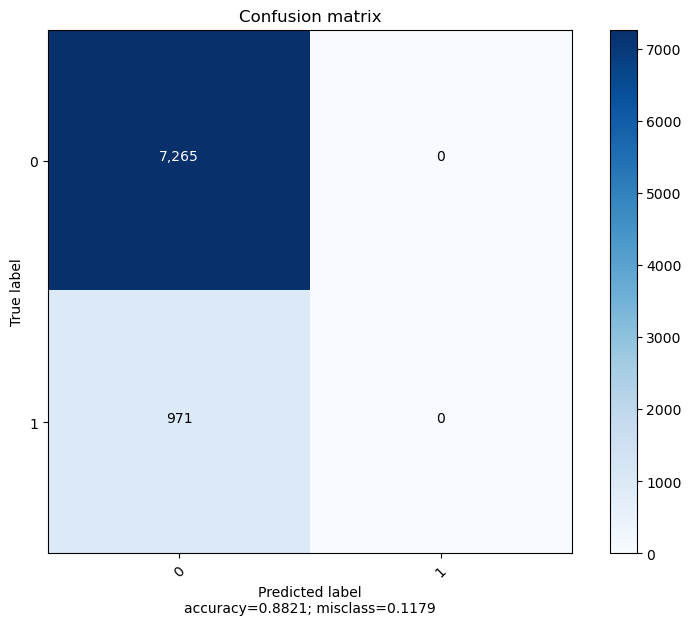


Treinando com weight_decay = 0.01
Epoch 010: | Train Loss: 0.351 | Val Loss: 0.3502 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 020: | Train Loss: 0.351 | Val Loss: 0.3500 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 030: | Train Loss: 0.351 | Val Loss: 0.3500 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 040: | Train Loss: 0.351 | Val Loss: 0.3500 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 050: | Train Loss: 0.351 | Val Loss: 0.3500 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 060: | Train Loss: 0.351 | Val Loss: 0.3500 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 070: | Train Loss: 0.351 | Val Loss: 0.3500 | Train Acc: 88.9417| Val Acc: 89.0000
Epoch 080: | Train Loss: 0.351 | Val Loss: 0.3500 | Train Acc: 88.9417| Val Acc: 89.0000
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7265
           1       0.00      0.00      0.00       971

    accuracy                           0.88      8236
   macro avg       0.44      0.50  

/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/carlos/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


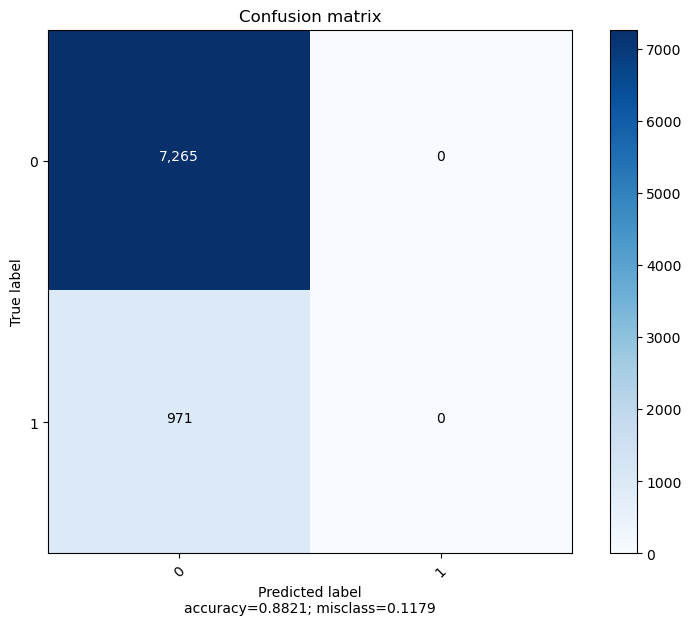

,weight_decay,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro
0,0.00,0.882103,0.468679,0.826847,0.441051,0.5
1,0.01,0.882103,0.468679,0.826847,0.441051,0.5


In [65]:
# 1. Fixar a arquitetura e os hiperparâmetros principais.
lr = 0.01
epochs = 80
hidden_neurons = 24
batch_size = 64
weight_decays = [0.0, 0.01]  # Sem L2 e com L2
resultados_l2 = {}

# 3. Para cada valor
for wd in weight_decays:
    print(f"\nTreinando com weight_decay = {wd}")
    
    
    modelo = NeuralNetwork(
        n_input=n_input,
        hidden_neurons=hidden_neurons,
        n_output=n_output,
        output_activation='sigmoid'
    ).to(device)
    
    
    optimizer = torch.optim.SGD(modelo.parameters(), lr=lr, weight_decay=wd)

    # Treinar o modelo
    hist = train_with_optimizer(
        modelo, train_loader, val_dataset, epochs, device, optimizer, binary=binary, skip=10
    )
    
    # Avaliar no conjunto de teste
    y_pred = modelo.predict(test_dataset.X_data.to(device), binary=binary)
    y_pred = y_pred.reshape(-1).astype(int)
    rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    #  Salvar resultados
    resultados_l2[wd] = {'history': hist, 'report': rep, 'confusion_matrix': cm}
    print(classification_report(y_test, y_pred))
    plot_confusion_matrix(cm)

# 4. Comparar accuracy, recall e F1, principalmente da classe minoritária.
tabela_l2 = []
for wd, res in resultados_l2.items():
    rep = res['report']
    tabela_l2.append({
        'weight_decay': wd,
        'accuracy': rep['accuracy'],
        'f1_macro': rep['macro avg']['f1-score'],
        'f1_weighted': rep['weighted avg']['f1-score'],
        'precision_macro': rep['macro avg']['precision'],
        'recall_macro': rep['macro avg']['recall']
    })
df_l2 = pd.DataFrame(tabela_l2)
display(df_l2)

### Comentários :

A motivação para testar regularização L2 (weight decay) foi pertinente: como a rede vinha apresentando soluções pouco equilibradas, fazia sentido investigar se penalizar pesos muito grandes poderia tornar o modelo mais estável ou mais robusto. Esse é um experimento clássico e bem justificado, porque regularização frequentemente ajuda a controlar complexidade e reduzir overfitting. Portanto, a escolha da análise foi adequada do ponto de vista metodológico.

Os resultados, porém, mostram que weight_decay = 0.01 não trouxe melhora em relação a weight_decay = 0.0. As métricas finais ficaram essencialmente iguais, com accuracy = 0.8821, F1 macro = 0.4687 e F1 weighted = 0.8268 nos dois cenários. Além disso, os relatórios de classificação continuam indicando colapso completo da classe 1, e os gráficos sugerem curvas praticamente sobrepostas. Isso mostra que a regularização, na intensidade testada, não alterou de forma relevante a dinâmica do modelo.

A conclusão mais correta, portanto, é que a motivação da análise foi boa, mas o efeito prático não apareceu. Isso não enfraquece o trabalho; pelo contrário, mostra que o experimento foi feito e avaliado com honestidade. Em um relatório bem escrito, esse tipo de resultado serve para reforçar que nem toda técnica clássica produz ganho automático e que o comportamento da rede depende fortemente do contexto específico do problema e da configuração global do pipeline.